In [16]:
# ==============================================================
# PROYECTO: Predicción de ley de Cu en yacimiento tipo veta (Chile)
# Interpolación espacial vecinal con Transformer + prior Matérn
# ==============================================================
# CELDA 1 (v3 PORTABLE) — Setup, imports y carga del dataset limpio
# ==============================================================
# Sin Google Drive. Obtención del dataset en cascada:
#   A) ya está junto al notebook (git clone o subida manual) -> se usa;
#   B) descarga directa desde raw.githubusercontent (con reintentos);
#   C) si raw devuelve 429 (rate limit típico de Colab), git clone
#      del repo (usa codeload, que no sufre ese límite) y se copia.
# Los resultados se guardan en ./resultados/ (se crea solo).

import os, time, shutil, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, warnings
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from scipy.spatial import cKDTree
warnings.filterwarnings('ignore')

# ---- Obtención portable del dataset --------------------------
REPO_URL   = 'https://github.com/ARSENICOX99/Proyecto-final-RNP'
RUTA_CLEAN = 'sondajes_clean.xlsx'

def _descarga_raw(destino, intentos=3):
    import urllib.request
    url = ('https://raw.githubusercontent.com/ARSENICOX99/'
           'Proyecto-final-RNP/main/sondajes_clean.xlsx')
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    for i in range(intentos):
        try:
            with urllib.request.urlopen(req, timeout=60) as r, \
                 open(destino, 'wb') as f:
                shutil.copyfileobj(r, f)
            return True
        except Exception as e:
            print(f"  intento {i+1}/{intentos} falló ({e}); reintentando...")
            time.sleep(5 * (i + 1))
    return False

def _descarga_clone(destino):
    tmp = '_repo_tmp'
    shutil.rmtree(tmp, ignore_errors=True)
    r = subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, tmp],
                       capture_output=True, text=True)
    src = os.path.join(tmp, 'sondajes_clean.xlsx')
    if r.returncode == 0 and os.path.exists(src):
        shutil.copy(src, destino)
        shutil.rmtree(tmp, ignore_errors=True)
        return True
    print(r.stderr[-500:])
    return False

if not os.path.exists(RUTA_CLEAN):
    print("sondajes_clean.xlsx no encontrado localmente — obteniendo del repo...")
    ok = _descarga_raw(RUTA_CLEAN)
    if not ok:
        print("raw.githubusercontent limitado (429) — usando git clone...")
        ok = _descarga_clone(RUTA_CLEAN)
    if not ok:
        raise FileNotFoundError(
            "No se pudo obtener sondajes_clean.xlsx automáticamente. "
            f"Descárgalo manualmente de {REPO_URL} y súbelo junto al notebook.")
    print("✓ Dataset obtenido.")

RUTA_OUT = 'resultados/'          # todas las celdas guardan aquí
os.makedirs(RUTA_OUT, exist_ok=True)

# ---- Reproducibilidad ----------------------------------------
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)   # fija numpy + python + tensorflow

# ---- Columnas del dataset ------------------------------------
COORDS       = ['X', 'Y', 'Z']           # metros reales (para distancias/kernel)
FEATURES_NUM = ['DIP', 'AZIMUT', 'FROM'] # numéricas contextuales -> scaler
FEATURE_CAT  = 'LITOLOGIA'               # categórica -> embedding
TARGET       = 'CUT'                     # ley de cobre (%)
HOLE         = 'HOLE-ID'

# ---- Carga ---------------------------------------------------
df = pd.read_excel(RUTA_CLEAN)
df = df.sort_values([HOLE, 'FROM']).reset_index(drop=True)

print(f"Dataset cargado: {df.shape[0]:,} intervalos | {df[HOLE].nunique()} sondajes")
print(f"Columnas: {list(df.columns)}")
print(f"\nCUT (ley Cu %): min={df[TARGET].min():.3f}  mediana={df[TARGET].median():.3f}  "
      f"max={df[TARGET].max():.3f}  skew={df[TARGET].skew():.2f}")
print(f"Resultados se guardarán en: {os.path.abspath(RUTA_OUT)}")

Dataset cargado: 122,926 intervalos | 1269 sondajes
Columnas: ['HOLE-ID', 'FROM', 'TO', 'LARGO', 'CUT', 'X', 'Y', 'Z', 'DIP', 'AZIMUT', 'LITOLOGIA', 'LITO_IMPUTADA']

CUT (ley Cu %): min=0.000  mediana=0.160  max=4.079  skew=3.55
Resultados se guardarán en: /content/resultados


In [17]:
# ==============================================================
# CELDA 2 — Split ESPACIAL por bloques 3D (anti-fuga)
# ==============================================================
# Motivo: los sondajes salen en abanico desde plataformas comunes
# (collares a ~0.6 m de mediana), así que separar por HOLE-ID NO
# separa en el espacio: el 21% de un test-por-sondaje tendría un
# dato de train a <2 m. Dividimos el yacimiento en bloques de 100 m
# y asignamos bloques ENTEROS a train/val/test, de modo que el test
# quede geográficamente apartado (interpolación honesta, como exige
# la validación espacial de Chauke 2026 y refs. del proyecto).

BLOCK_SIZE = 100.0                      # metros
SPLIT_FRAC = (0.70, 0.15, 0.15)         # train, val, test (objetivo por nº de intervalos)

# ---- 1. Asignar cada intervalo a un bloque 3D ----------------
_bx = np.floor((df['X'] - df['X'].min()) / BLOCK_SIZE).astype(int)
_by = np.floor((df['Y'] - df['Y'].min()) / BLOCK_SIZE).astype(int)
_bz = np.floor((df['Z'] - df['Z'].min()) / BLOCK_SIZE).astype(int)
df['BLOCK'] = _bx.astype(str) + '_' + _by.astype(str) + '_' + _bz.astype(str)

# ---- 2. Repartir bloques balanceando por nº de intervalos ----
# Greedy: bloques de mayor a menor, cada uno va a la partición más
# "vacía" respecto a su cupo objetivo. Determinista (no aleatorio).
block_sizes = df.groupby('BLOCK').size().sort_values(ascending=False)
N_total = len(df)
cupo   = {'train': SPLIT_FRAC[0]*N_total,
          'val'  : SPLIT_FRAC[1]*N_total,
          'test' : SPLIT_FRAC[2]*N_total}
acum   = {'train': 0, 'val': 0, 'test': 0}
asign  = {}
for blk, sz in block_sizes.items():
    # partición con mayor déficit relativo (cupo restante / cupo total)
    deficit = {k: (cupo[k] - acum[k]) / cupo[k] for k in cupo}
    destino = max(deficit, key=deficit.get)
    asign[blk] = destino
    acum[destino] += sz

df['SPLIT'] = df['BLOCK'].map(asign)

df_train = df[df['SPLIT'] == 'train'].copy()
df_val   = df[df['SPLIT'] == 'val'].copy()
df_test  = df[df['SPLIT'] == 'test'].copy()

# ---- 3. Reporte + verificación de fuga -----------------------
print("Split espacial por bloques de {:.0f} m ({} bloques):".format(
    BLOCK_SIZE, df['BLOCK'].nunique()))
for name, d_ in [('train', df_train), ('val', df_val), ('test', df_test)]:
    print(f"  {name:5s}: {len(d_):>7,} intervalos ({100*len(d_)/N_total:4.1f}%) | "
          f"{d_['BLOCK'].nunique():>3} bloques | {d_[HOLE].nunique():>4} sondajes")

_tree = cKDTree(df_train[COORDS].values)
_d, _ = _tree.query(df_test[COORDS].values, k=1)
print(f"\nFuga espacial residual (dist. test->train más cercano):")
print(f"  mediana={np.median(_d):.1f} m | % a <2 m={100*np.mean(_d<2):.1f}% | "
      f"% a <10 m={100*np.mean(_d<10):.1f}%")
print("  (comparar: split por sondaje daba 21.5% a <2 m — fuga eliminada)")

Split espacial por bloques de 100 m (153 bloques):
  train:  86,047 intervalos (70.0%) | 112 bloques | 1161 sondajes
  val  :  18,440 intervalos (15.0%) |  21 bloques |  410 sondajes
  test :  18,439 intervalos (15.0%) |  20 bloques |  357 sondajes

Fuga espacial residual (dist. test->train más cercano):
  mediana=22.0 m | % a <2 m=2.4% | % a <10 m=18.6%
  (comparar: split por sondaje daba 21.5% a <2 m — fuga eliminada)


In [18]:
# ==============================================================
# CELDA 3 — Normalización de features + transform del target
# ==============================================================
# - Features numéricas contextuales (DIP, AZIMUT, FROM): StandardScaler,
#   fit SOLO en train.
# - Coordenadas X,Y,Z: NO se tocan (el kernel Matérn y el KD-tree las
#   necesitan en METROS reales). Esto evita el bug del Geo-3D viejo,
#   que escalaba y luego restauraba coords a mano.
# - Target CUT: log1p + z-score con parámetros de TRAIN (sin leakage).
#   CUT es lognormal (skew alto); log1p simetriza, z-score la lleva a
#   ~N(0,1) para estabilizar el entrenamiento. Reversible exacto a %Cu.

# ---- 1. Scaler de features numéricas (fit en train) ----------
scaler = StandardScaler().fit(df_train[FEATURES_NUM])

def escalar_features(dfx):
    out = dfx.copy()
    out[FEATURES_NUM] = scaler.transform(dfx[FEATURES_NUM])
    return out

df_train_s = escalar_features(df_train)
df_val_s   = escalar_features(df_val)
df_test_s  = escalar_features(df_test)
# ---- 1b. Guardar FROM REAL (metros) antes de escalar ---------
# escalar_features() escala FEATURES_NUM (incluye FROM) sobre una copia.
# Tomamos FROM del df ORIGINAL (sin escalar) para trazabilidad al evaluar.
df_train_s['FROM_REAL'] = df_train['FROM'].values
df_val_s['FROM_REAL']   = df_val['FROM'].values
df_test_s['FROM_REAL']  = df_test['FROM'].values

# ---- 2. Transform del target (log1p + z-score, params de train) --
log_cut_train = np.log1p(df_train[TARGET].values)
CUT_LOG_MEAN  = float(log_cut_train.mean())
CUT_LOG_STD   = float(log_cut_train.std())

def transform_target(cut_raw):
    return (np.log1p(cut_raw) - CUT_LOG_MEAN) / CUT_LOG_STD

def inverse_target(cut_z):
    """z-score log -> %Cu real. Usar SIEMPRE al evaluar."""
    return np.expm1(cut_z * CUT_LOG_STD + CUT_LOG_MEAN)

for dfx in (df_train_s, df_val_s, df_test_s):
    dfx[TARGET] = transform_target(dfx[TARGET].values)

target_transform = {'log_mean': CUT_LOG_MEAN, 'log_std': CUT_LOG_STD}

# ---- 3. Verificación ----------------------------------------
print("Features escaladas (fit en train):", FEATURES_NUM)
print(f"  medias train: {scaler.mean_.round(3)}")
print(f"  stds   train: {scaler.scale_.round(3)}")
print(f"\nCoordenadas {COORDS}: SIN escalar (metros reales para el kernel).")
print(f"\nTarget CUT -> log1p + z-score:")
print(f"  log_mean(train)={CUT_LOG_MEAN:.4f}  log_std(train)={CUT_LOG_STD:.4f}")
print(f"  y_train: mean={df_train_s[TARGET].mean():.3f} std={df_train_s[TARGET].std():.3f}")
print(f"  y_test : mean={df_test_s[TARGET].mean():.3f} std={df_test_s[TARGET].std():.3f}  "
      f"(≠0 es normal: test es otra zona)")

# check de reversibilidad
_chk = inverse_target(transform_target(df_test[TARGET].values))
print(f"\n  Reversibilidad target (max err): {np.abs(_chk - df_test[TARGET].values).max():.2e}")

Features escaladas (fit en train): ['DIP', 'AZIMUT', 'FROM']
  medias train: [-23.789 193.368  65.942]
  stds   train: [ 36.965 132.065  59.911]

Coordenadas ['X', 'Y', 'Z']: SIN escalar (metros reales para el kernel).

Target CUT -> log1p + z-score:
  log_mean(train)=0.2754  log_std(train)=0.3281
  y_train: mean=-0.000 std=1.000
  y_test : mean=-0.208 std=0.796  (≠0 es normal: test es otra zona)

  Reversibilidad target (max err): 1.33e-15


In [19]:
# ==============================================================
# CELDA 4 — Construcción de vecindarios espaciales (K-NN 3D)
# ==============================================================
# Cada MUESTRA = un punto objetivo + sus K vecinos espaciales tomados
# SIEMPRE del soporte train (como kriging: interpolar desde lo conocido).
#
# Arregla los 3 bugs que colapsaron el Geo-3D viejo:
#  (1) LEAKAGE DE VECINDARIO: para train, se excluyen los vecinos a
#      < R_MIN metros del objetivo (evita "copiar" el intervalo contiguo
#      del mismo sondaje, a ~1 m, que en test no existe).
#  (2) ESCALA: delta se guarda en METROS reales; devolvemos también la
#      distancia mediana para inicializar el kernel Matérn a la escala
#      correcta (no un valor arbitrario).
#  (3) VECINOS VÁLIDOS: si un punto no tiene K vecinos dentro de R_MAX,
#      se rellena con padding y una máscara los desactiva en la atención.

K_VECINOS = 24          # nº de vecinos (Chauke usa k=16; veta pide algo más)
R_MIN     = 3.0         # m: radio de exclusión anti-leakage (train)
R_MAX     = 150.0       # m: más allá, el vecino no informa (se enmascara)

def construir_vecindarios(df_tgt, df_sup, exclude_self_radius=0.0):
    """
    df_tgt : puntos a predecir (train/val/test escalados)
    df_sup : SOPORTE de vecinos = SIEMPRE df_train_s
    exclude_self_radius : R_MIN para train (excluye vecinos demasiado
                          cercanos = mismo abanico); 0 para val/test.
    Devuelve dict con tensores listos para el modelo + máscara + meta.
    """
    coords_sup = df_sup[COORDS].values                     # metros reales
    coords_tgt = df_tgt[COORDS].values
    tree = cKDTree(coords_sup)

    # pedimos K extra para poder descartar los que caen bajo R_MIN

    k_query = K_VECINOS + 40
    k_query = min(k_query, len(coords_sup))
    dist, idx = tree.query(coords_tgt, k=k_query)          # (N, k_query)

    sup_feat = df_sup[FEATURES_NUM].values.astype(np.float32)
    sup_lit  = df_sup[FEATURE_CAT].values.astype(np.int32)
    sup_cut  = df_sup[TARGET].values.astype(np.float32)     # ya transformado (z-log)

    N = len(coords_tgt)
    kv_feat = np.zeros((N, K_VECINOS, len(FEATURES_NUM)), np.float32)
    kv_lit  = np.zeros((N, K_VECINOS), np.int32)
    kv_cut  = np.zeros((N, K_VECINOS, 1), np.float32)
    delta   = np.zeros((N, K_VECINOS, 3), np.float32)       # metros reales
    mask    = np.zeros((N, K_VECINOS), np.float32)          # 1=vecino válido

    for i in range(N):
        di, ii = dist[i], idx[i]
        # filtro anti-leakage + rango máximo
        valid = (di >= exclude_self_radius) & (di <= R_MAX)
        ii = ii[valid][:K_VECINOS]
        nk = len(ii)
        if nk == 0:                      # punto aislado: deja todo enmascarado
            continue
        kv_feat[i, :nk] = sup_feat[ii]
        kv_lit[i, :nk]  = sup_lit[ii]
        kv_cut[i, :nk, 0] = sup_cut[ii]
        delta[i, :nk]   = (coords_sup[ii] - coords_tgt[i]).astype(np.float32)
        mask[i, :nk]    = 1.0

    return {
        'q_feat': df_tgt[FEATURES_NUM].values.astype(np.float32),
        'q_lit' : df_tgt[FEATURE_CAT].values.astype(np.int32),
        'kv_feat': kv_feat, 'kv_lit': kv_lit, 'kv_cut': kv_cut,
        'delta': delta, 'mask': mask,
        'y': df_tgt[TARGET].values.astype(np.float32),
        'meta': list(zip(df_tgt[HOLE].astype(str).values,
                         np.round(df_tgt['FROM_REAL'].values, 3))),  # FROM real en metros
    }



print("Construyendo vecindarios (soporte = train)...")
data_train = construir_vecindarios(df_train_s, df_train_s, exclude_self_radius=R_MIN)
data_val   = construir_vecindarios(df_val_s,   df_train_s, exclude_self_radius=0.0)
data_test  = construir_vecindarios(df_test_s,  df_train_s, exclude_self_radius=0.0)

# ---- Diagnóstico del vecindario (clave para el kernel) -------
_d_all = np.linalg.norm(data_test['delta'], axis=-1)
_d_val = _d_all[data_test['mask'] > 0]
DIST_MEDIANA = float(np.median(_d_val))
print(f"\nMuestras: train={len(data_train['y']):,}  "
      f"val={len(data_val['y']):,}  test={len(data_test['y']):,}")
print(f"Vecinos válidos por punto (test): "
      f"media={data_test['mask'].sum(1).mean():.1f}/{K_VECINOS}")
print(f"% puntos test con vecindario completo: "
      f"{100*np.mean(data_test['mask'].sum(1)==K_VECINOS):.1f}%")
print(f"Distancia mediana objetivo->vecino (test): {DIST_MEDIANA:.1f} m")
print(f"  -> se usará para inicializar los rangos del kernel Matérn")

Construyendo vecindarios (soporte = train)...

Muestras: train=86,047  val=18,440  test=18,439
Vecinos válidos por punto (test): media=24.0/24
% puntos test con vecindario completo: 100.0%
Distancia mediana objetivo->vecino (test): 25.9 m
  -> se usará para inicializar los rangos del kernel Matérn


In [20]:
# ==============================================================
# CELDA 4b — Utilidades de evaluación (usar en TODOS los modelos)
# ==============================================================
from scipy.stats import spearmanr

def metricas_basicas(y_true, y_pred, nombre, verbose=True):
    """Métricas en %Cu real. VarRatio~1 = sin sobre-suavizado."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    mae   = np.mean(np.abs(y_true - y_pred))
    rmse  = np.sqrt(np.mean((y_true - y_pred)**2))
    medae = np.median(np.abs(y_true - y_pred))
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    r2    = 1 - ss_res/ss_tot
    # SMAPE robusto (evita división por cero)
    denom = (np.abs(y_true) + np.abs(y_pred))
    smape = 100 * np.mean(np.where(denom > 0, np.abs(y_true - y_pred)/denom, 0.0)) * 2
    rho   = spearmanr(y_true, y_pred).correlation
    vr    = np.var(y_pred) / np.var(y_true) if np.var(y_true) > 0 else 0.0
    if verbose:
        print(f"\n{'='*52}\n{nombre} — test espacial (%Cu real)\n{'='*52}")
        print(f"  MAE      : {mae:.4f}")
        print(f"  RMSE     : {rmse:.4f}")
        print(f"  R²       : {r2:.4f}")
        print(f"  MedAE    : {medae:.4f}")
        print(f"  SMAPE    : {smape:.2f}%")
        print(f"  Spearman : {rho:.4f}   (ordenamiento de leyes)")
        print(f"  VarRatio : {vr:.4f}   (var_pred/var_real; ~1 = sin aplanar)")
    return {'modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
            'MedAE': medae, 'SMAPE': smape, 'Spearman': rho, 'VarRatio': vr}

print("metricas_basicas() lista — disponible para IK, Transformer y demás.")

metricas_basicas() lista — disponible para IK, Transformer y demás.


In [21]:
# ==============================================================
# CELDA 5 (v2) — BASELINE: Indicator Kriging REAL (sistema kriging)
# ==============================================================
# IK ordinario local resuelto a mano (validado vs pykrige a 1e-14):
#  1) por cada umbral, ajusta variograma exponencial del indicador
#     (con submuestra, rápido) para extraer [psill, range, nugget];
#  2) para cada punto de test, resuelve el sistema kriging ordinario
#     con sus N_VECINOS de train -> P(CUT <= umbral);


!pip install pykrige -q

from pykrige.ok3d import OrdinaryKriging3D
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from scipy.linalg import solve
from sklearn.isotonic import IsotonicRegression
import time, os, pickle

# ---- Datos en %Cu REAL ---------------------------------------
pts_tr   = df_train[COORDS].values                    # soporte
pts_te   = df_test[COORDS].values                     # puntos a estimar
cut_tr   = df_train[TARGET].values.astype(np.float64) # %Cu real (sin transformar)
cut_te   = df_test[TARGET].values.astype(np.float64)  # verdad de terreno
n_te     = len(pts_te)

# ---- Umbrales (deciles de train) -----------------------------
K_UMBRALES = 7
percentiles = np.linspace(10, 90, K_UMBRALES)
umbrales = np.percentile(cut_tr, percentiles)
print("Umbrales IK (%Cu):", np.round(umbrales, 4))

# ---- Config kriging ------------------------------------------
N_VARIOGRAMA = 2000    # submuestra para ajustar variograma (rápido)
N_VECINOS    = 40      # vecinos reales por punto (sistema kriging local)

np.random.seed(42)
idx_v   = np.random.choice(len(pts_tr), size=min(N_VARIOGRAMA, len(pts_tr)), replace=False)
sub_pts = pts_tr[idx_v]
sub_cut = cut_tr[idx_v]

tree = cKDTree(pts_tr)
print(f"Buscando {N_VECINOS} vecinos para {n_te:,} puntos de test...")
_, vecinos_idx = tree.query(pts_te, k=N_VECINOS)      # (n_te, N_VECINOS)

def vario_exp(h, psill, rng, nug):
    return psill * (1.0 - np.exp(-h / rng)) + nug

CKPT = RUTA_OUT + 'F_hat_ik_ckpt.pkl'
F_hat = np.zeros((n_te, K_UMBRALES))
k_start = 0
if os.path.exists(CKPT):                               # reanudar si se cortó
    F_hat, k_done = pickle.load(open(CKPT, 'rb'))
    k_start = k_done + 1
    print(f"Reanudando desde umbral {k_start+1}")

print(f"\nIK real (soporte {len(pts_tr):,} pts, {N_VECINOS} vecinos/punto):")
for k in range(k_start, K_UMBRALES):
    t_k = umbrales[k]; t0 = time.time()

    # 1) variograma del indicador (submuestra)
    ind_sub = (sub_cut <= t_k).astype(float)
    try:
        ok = OrdinaryKriging3D(sub_pts[:,0], sub_pts[:,1], sub_pts[:,2], ind_sub,
                               variogram_model='exponential', nlags=15,
                               weight=True, verbose=False, enable_plotting=False)
        psill, rng, nug = ok.variogram_model_parameters
    except Exception as e:
        print(f"  Umbral {k+1}: variograma falló ({e}) -> proporción global")
        F_hat[:, k] = ind_sub.mean(); continue

    # 2) indicadores sobre TODO el soporte train
    ind_full = (cut_tr <= t_k).astype(float)

# 3) sistema kriging ordinario local por punto (REGULARIZADO)
    probs = np.zeros(n_te)
    n_singular = 0
    for i in range(n_te):
        idx = vecinos_idx[i]
        pd_ = pts_tr[idx]; vd_ = ind_full[idx]; n = len(idx)
        G = vario_exp(cdist(pd_, pd_), psill, rng, nug)
        A = np.zeros((n+1, n+1)); A[:n,:n] = G; A[:n,n] = 1.0; A[n,:n] = 1.0
        # REGULARIZACIÓN: nugget numérico en la diagonal (Tikhonov).
        # Evita matrices singulares por vecinos casi coincidentes (abanicos).
        A[:n, :n] += np.eye(n) * (psill * 1e-4 + 1e-8)
        b = np.zeros(n+1); b[:n] = vario_exp(cdist([pts_te[i]], pd_)[0], psill, rng, nug); b[n] = 1.0
        try:
            w = solve(A, b, assume_a='sym')
            p = w[:n] @ vd_
            # SALVAGUARDA: si el peso explota (mal condicionamiento residual),
            # cae a promedio local. Una prob válida jamás sale de [0,1].
            if not np.isfinite(p) or abs(p) > 5.0:
                p = vd_.mean(); n_singular += 1
        except Exception:
            p = vd_.mean(); n_singular += 1
        probs[i] = p
    F_hat[:, k] = np.clip(probs, 0.0, 1.0)
    pickle.dump((F_hat, k), open(CKPT, 'wb'))
    print(f"  Umbral {k+1}/{K_UMBRALES}  t={t_k:.4f}  P̄={probs.mean():.3f}  "
          f"singulares={n_singular}  ({time.time()-t0:.0f}s) ✓")

# ---- Monotonicidad de la CDF (isotónica) ---------------------
ir = IsotonicRegression(increasing=True, out_of_bounds='clip')
for i in range(n_te):
    F_hat[i] = ir.fit_transform(np.arange(K_UMBRALES), F_hat[i])

# ---- Reconstrucción E[CUT] (integral de supervivencia) -------
CUT_MIN, CUT_MAX = 0.0, np.quantile(cut_tr, 0.99)
t_ext = np.concatenate([[CUT_MIN], umbrales, [CUT_MAX]])
F_ext = np.hstack([np.zeros((n_te,1)), F_hat, np.ones((n_te,1))])
delta_t = np.diff(t_ext)
S_mid = 1 - 0.5*(F_ext[:,:-1] + F_ext[:,1:])
ik_pred = np.clip((S_mid * delta_t).sum(axis=1), 0, None)

# ---- Métricas ------------------------------------------------
res_ik = metricas_basicas(cut_te, ik_pred, "Indicator Kriging (real)")
resultados = [res_ik]
np.save(RUTA_OUT + 'ik_pred_test.npy', ik_pred)
print("\n✓ IK real completado sobre split espacial honesto.")

Umbrales IK (%Cu): [0.03  0.07  0.113 0.18  0.25  0.421 1.038]
Buscando 40 vecinos para 18,439 puntos de test...
Reanudando desde umbral 8

IK real (soporte 86,047 pts, 40 vecinos/punto):

Indicator Kriging (real) — test espacial (%Cu real)
  MAE      : 0.2997
  RMSE     : 0.5511
  R²       : -0.1521
  MedAE    : 0.1457
  SMAPE    : 89.51%
  Spearman : 0.2644   (ordenamiento de leyes)
  VarRatio : 0.3558   (var_pred/var_real; ~1 = sin aplanar)

✓ IK real completado sobre split espacial honesto.


In [22]:
# Guardar predicciones + métricas del baseline (para no recalcular)
np.save(RUTA_OUT + 'ik_pred_test.npy', ik_pred)
import json
json.dump(res_ik, open(RUTA_OUT + 'res_ik.json', 'w'))
print("✓ ik_pred_test.npy y res_ik.json guardados.")

✓ ik_pred_test.npy y res_ik.json guardados.


In [23]:
# ==============================================================
# CELDA 6a — Capa KrigingAttention (atención vecinal con prior Matérn)
# ==============================================================
# Atención cruzada query(objetivo) -> K vecinos de train, con un SESGO
# ADITIVO en los logits proporcional a un kernel Matérn sobre la
# distancia 3D real (delta en metros). Es "kriging aprendible":
#   - la parte por contenido (Q·K) modula según geología/orientación;
#   - el prior Matérn favorece a los vecinos espacialmente cercanos.
# El rango (length-scale) rho y el peso beta del prior son APRENDIBLES,
# inicializados a la escala real del vecindario (DIST_MEDIANA).
# nu=1.5 -> campo una vez diferenciable (típico en geoestadística).

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class KrigingAttention(layers.Layer):
    def __init__(self, d_model, n_heads, nu=1.5, rho_init=None, **kwargs):
        super().__init__(**kwargs)
        assert d_model % n_heads == 0, "d_model debe ser divisible por n_heads"
        self.d_model  = d_model
        self.n_heads  = n_heads
        self.d_head   = d_model // n_heads
        self.nu       = nu
        # escala inicial del prior: distancia mediana objetivo->vecino (m)
        self.rho_init = float(rho_init) if rho_init is not None else 50.0

        self.wq = layers.Dense(d_model)
        self.wk = layers.Dense(d_model)
        self.wv = layers.Dense(d_model)
        self.wo = layers.Dense(d_model)

    def build(self, input_shape):
        # log_rho: length-scale por cabeza (aprendible), init a la escala real
        self.log_rho = self.add_weight(
            name='log_rho', shape=(self.n_heads,),
            initializer=keras.initializers.Constant(np.log(self.rho_init)),
            trainable=True)
        # beta: peso del prior espacial vs. atención por contenido (por cabeza)
        self.beta = self.add_weight(
            name='beta', shape=(self.n_heads,),
            initializer=keras.initializers.Constant(1.0), trainable=True)
        super().build(input_shape)

    def _matern(self, r):
        # r: distancia normalizada = dist / rho  (>=0)
        if abs(self.nu - 0.5) < 1e-6:
            return tf.exp(-r)
        elif abs(self.nu - 1.5) < 1e-6:
            s = np.sqrt(3.0) * r
            return (1.0 + s) * tf.exp(-s)
        else:  # nu = 2.5
            s = np.sqrt(5.0) * r
            return (1.0 + s + s**2 / 3.0) * tf.exp(-s)

    def _split_heads(self, x):
        # (B, T, d_model) -> (B, H, T, d_head)
        B = tf.shape(x)[0]; T = tf.shape(x)[1]
        x = tf.reshape(x, (B, T, self.n_heads, self.d_head))
        return tf.transpose(x, (0, 2, 1, 3))

    def call(self, q, kv, delta, mask):
        # q:(B,1,d)  kv:(B,K,d)  delta:(B,K,3) metros  mask:(B,K) 1=válido
        Q = self._split_heads(self.wq(q))    # (B,H,1,d_head)
        K = self._split_heads(self.wk(kv))   # (B,H,K,d_head)
        V = self._split_heads(self.wv(kv))   # (B,H,K,d_head)

        # 1) atención por contenido (geología, orientación, CUT del vecino)
        scores = tf.matmul(Q, K, transpose_b=True)                 # (B,H,1,K)
        scores = scores / tf.math.sqrt(tf.cast(self.d_head, tf.float32))

        # 2) prior Matérn sobre la distancia 3D real objetivo->vecino
        dist = tf.sqrt(tf.reduce_sum(delta**2, axis=-1) + 1e-9)    # (B,K)
        dist = dist[:, tf.newaxis, tf.newaxis, :]                  # (B,1,1,K)
        rho  = tf.reshape(tf.exp(self.log_rho), (1, self.n_heads, 1, 1))
        prior = self._matern(dist / (rho + 1e-6))                 # (B,H,1,K) en (0,1]
        beta  = tf.reshape(self.beta, (1, self.n_heads, 1, 1))
        # sesgo aditivo en logits: log-kernel -> vecinos lejanos penalizados
        scores = scores + beta * tf.math.log(prior + 1e-9)

        # 3) enmascarar vecinos padding
        m = mask[:, tf.newaxis, tf.newaxis, :]                     # (B,1,1,K)
        neg = tf.fill(tf.shape(scores), tf.constant(-1e9, tf.float32))
        scores = tf.where(m > 0, scores, neg)

        w = tf.nn.softmax(scores, axis=-1)                         # (B,H,1,K)
        out = tf.matmul(w, V)                                      # (B,H,1,d_head)

        # recombinar cabezas -> (B,1,d_model)
        B = tf.shape(out)[0]
        out = tf.transpose(out, (0, 2, 1, 3))                      # (B,1,H,d_head)
        out = tf.reshape(out, (B, 1, self.d_model))
        return self.wo(out)

    def get_config(self):
        cfg = super().get_config()
        cfg.update(dict(d_model=self.d_model, n_heads=self.n_heads,
                        nu=self.nu, rho_init=self.rho_init))
        return cfg

print("KrigingAttention lista (prior Mat\u00e9rn aprendible, escala =",
      "DIST_MEDIANA si est\u00e1 definida).")


KrigingAttention lista (prior Matérn aprendible, escala = DIST_MEDIANA si está definida).


In [24]:
# ==============================================================
# CELDA 6b — Constructor del Transformer espacial (Kriging-Attention)
# ==============================================================
# Objetivo -> atiende a K vecinos de train (con su CUT, litología,
# orientación y delta 3D). Apila bloques de KrigingAttention + FFN.
# El vecino aporta su CUT: el modelo aprende a ponderar/combinar leyes
# vecinas guiado por geología + prior Matérn (kriging aprendible).

def construir_transformer_espacial(n_feat, n_lito, K, d_model=64, n_heads=4,
                                   n_blocks=2, d_ff=128, emb_dim=8,
                                   dropout=0.15):
    in_q_feat = keras.Input((n_feat,),      name='q_feat')
    in_q_lit  = keras.Input((),  dtype='int32', name='q_lit')
    in_kv_feat= keras.Input((K, n_feat),    name='kv_feat')
    in_kv_lit = keras.Input((K,), dtype='int32', name='kv_lit')
    in_kv_cut = keras.Input((K, 1),         name='kv_cut')
    in_delta  = keras.Input((K, 3),         name='delta')
    in_mask   = keras.Input((K,),           name='mask')

    emb = layers.Embedding(n_lito, emb_dim, name='emb_lito')

    # Query: features del objetivo + su litología -> d_model
    q = layers.Concatenate()([in_q_feat, emb(in_q_lit)])
    q = layers.Dense(d_model, activation='gelu')(q)
    q = layers.Reshape((1, d_model))(q)

    # KV: vecinos = features + litología + SU CUT (la info clave)
    kv = layers.Concatenate()([in_kv_feat, emb(in_kv_lit), in_kv_cut])
    kv = layers.Dense(d_model, activation='gelu')(kv)

    x = q
    for _ in range(n_blocks):
        attn = KrigingAttention(d_model, n_heads)(x, kv, in_delta, in_mask)
        x = layers.LayerNormalization()(x + layers.Dropout(dropout)(attn))
        ff = keras.Sequential([layers.Dense(d_ff, activation='gelu'),
                               layers.Dense(d_model)])(x)
        x = layers.LayerNormalization()(x + layers.Dropout(dropout)(ff))

    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, name='cut')(x)                 # predice CUT en z-log
    out = layers.Reshape((1,), name='cut_out')(out)

    model = keras.Model(
        inputs=[in_q_feat, in_q_lit, in_kv_feat, in_kv_lit, in_kv_cut, in_delta, in_mask],
        outputs=out)
    return model

def to_inputs(d):
    """dict de vecindarios -> inputs del modelo (mismo orden)."""
    return {'q_feat': d['q_feat'], 'q_lit': d['q_lit'],
            'kv_feat': d['kv_feat'], 'kv_lit': d['kv_lit'],
            'kv_cut': d['kv_cut'], 'delta': d['delta'], 'mask': d['mask']}

# ---- Instanciar ----------------------------------------------
N_FEAT = len(FEATURES_NUM)
N_LITO = int(df[FEATURE_CAT].max()) + 1
modelo = construir_transformer_espacial(N_FEAT, N_LITO, K_VECINOS)
modelo.compile(optimizer=keras.optimizers.Adam(5e-4), loss='mae', metrics=['mae'])
print(f"Transformer espacial: {modelo.count_params():,} parámetros")
print(f"  N_FEAT={N_FEAT}  N_LITO={N_LITO}  K={K_VECINOS}")

Transformer espacial: 68,713 parámetros
  N_FEAT=3  N_LITO=11  K=24


In [25]:
# ==============================================================
# CELDA 7 — Entrenamiento del Transformer espacial
# ==============================================================
# - Loss: MAE en z-log (robusto a la cola de altas leyes).
# - Early stopping sobre val_loss + restauración del mejor peso.
# - Callback propio: vigila el VarRatio en val cada época. Si el modelo
#   colapsa a la media (VarRatio -> 0, el fallo del Geo-3D viejo), lo
#   veremos en vivo en vez de al final.

X_train = to_inputs(data_train); y_train = data_train['y']
X_val   = to_inputs(data_val);   y_val   = data_val['y']

class VigilarVarRatio(keras.callbacks.Callback):
    """Reporta var(pred)/var(real) en val: ~1 sano, ->0 = colapso a la media."""
    def __init__(self, Xv, yv, cada=3):
        super().__init__(); self.Xv = Xv; self.yv = yv; self.cada = cada
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.cada == 0:
            p = self.model.predict(self.Xv, verbose=0).ravel()
            vr = np.var(p) / np.var(self.yv)
            rho = spearmanr(self.yv, p).correlation
            print(f"    [ep {epoch+1}] val VarRatio={vr:.3f}  Spearman={rho:.3f}"
                  + ("   ⚠ colapsando" if vr < 0.05 else ""))

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, min_lr=1e-5, verbose=1),
    VigilarVarRatio(X_val, y_val, cada=3),
]

print("Entrenando Transformer espacial...\n")
hist = modelo.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=256,
    callbacks=callbacks, verbose=2,
)
print("\n✓ Entrenamiento terminado.")

# guardar modelo + history
modelo.save(RUTA_OUT + 'transformer_espacial.keras')
pickle.dump(hist.history, open(RUTA_OUT + 'history_transformer.pkl', 'wb'))
print("✓ Modelo y history guardados.")

Entrenando Transformer espacial...

Epoch 1/100
337/337 - 75s - 221ms/step - loss: 0.5817 - mae: 0.5817 - val_loss: 0.5015 - val_mae: 0.5015 - learning_rate: 5.0000e-04
Epoch 2/100
337/337 - 64s - 191ms/step - loss: 0.4725 - mae: 0.4725 - val_loss: 0.4972 - val_mae: 0.4972 - learning_rate: 5.0000e-04
Epoch 3/100
    [ep 3] val VarRatio=0.194  Spearman=0.397
337/337 - 42s - 126ms/step - loss: 0.4595 - mae: 0.4595 - val_loss: 0.4946 - val_mae: 0.4946 - learning_rate: 5.0000e-04
Epoch 4/100
337/337 - 74s - 219ms/step - loss: 0.4522 - mae: 0.4522 - val_loss: 0.4968 - val_mae: 0.4968 - learning_rate: 5.0000e-04
Epoch 5/100
337/337 - 38s - 113ms/step - loss: 0.4478 - mae: 0.4478 - val_loss: 0.5022 - val_mae: 0.5022 - learning_rate: 5.0000e-04
Epoch 6/100
    [ep 6] val VarRatio=0.261  Spearman=0.399
337/337 - 40s - 117ms/step - loss: 0.4434 - mae: 0.4434 - val_loss: 0.5060 - val_mae: 0.5060 - learning_rate: 5.0000e-04
Epoch 7/100
337/337 - 38s - 112ms/step - loss: 0.4393 - mae: 0.4393 - val_

In [26]:
# ==============================================================
# CELDA 8 — Evaluación en TEST + comparación contra IK
# ==============================================================
# Predice en test, revierte el target a %Cu real e informa el panel
# robusto. Compara punto a punto contra el IK (mismo test).

# ---- 1. Predicción en test (z-log) ---------------------------
pred_z = modelo.predict(to_inputs(data_test), verbose=0).ravel()

# ---- 2. Revertir a %Cu real ----------------------------------
tr_pred = inverse_target(pred_z)                 # Transformer, %Cu real
y_real  = df_test[TARGET].values.astype(float)   # verdad de terreno, %Cu real
#   (df_test[TARGET] está transformado en df_test_s, pero df_test crudo no;
#    ojo: usamos df_test ORIGINAL para la verdad en %Cu real)

# SALVAGUARDA: verificar que y_real está en %Cu real, no en z-log
assert y_real.max() > 2.0, "y_real parece estar en z-log, no en %Cu real"

# ---- 3. Panel robusto del Transformer ------------------------
res_tr = metricas_basicas(y_real, tr_pred, "Transformer espacial")

# ---- 4. Cargar IK y comparar sobre el MISMO test -------------
ik_pred = np.load(RUTA_OUT + 'ik_pred_test.npy')
res_ik  = json.load(open(RUTA_OUT + 'res_ik.json'))

print(f"\n{'='*64}\nCOMPARACIÓN FINAL — test espacial ({len(y_real):,} puntos)\n{'='*64}")
print(f"{'Métrica':<10}{'IK real':>14}{'Transformer':>16}")
print("-"*64)
for m in ['MAE', 'RMSE', 'R2', 'MedAE', 'SMAPE', 'Spearman', 'VarRatio']:
    print(f"{m:<10}{res_ik[m]:>14.4f}{res_tr[m]:>16.4f}")
print("="*64)

# ---- 5. Guardar tabla comparativa ----------------------------
import pandas as pd
tabla = pd.DataFrame([res_ik, res_tr]).set_index('modelo')
tabla.to_csv(RUTA_OUT + 'comparacion_ik_vs_transformer.csv')
print("\n✓ Tabla guardada: comparacion_ik_vs_transformer.csv")
print(tabla.round(4).to_string())


Transformer espacial — test espacial (%Cu real)
  MAE      : 0.2309
  RMSE     : 0.5269
  R²       : -0.0528
  MedAE    : 0.0894
  SMAPE    : 79.53%
  Spearman : 0.2866   (ordenamiento de leyes)
  VarRatio : 0.1233   (var_pred/var_real; ~1 = sin aplanar)

COMPARACIÓN FINAL — test espacial (18,439 puntos)
Métrica          IK real     Transformer
----------------------------------------------------------------
MAE               0.2997          0.2309
RMSE              0.5511          0.5269
R2               -0.1521         -0.0528
MedAE             0.1457          0.0894
SMAPE            89.5084         79.5282
Spearman          0.2644          0.2866
VarRatio          0.3558          0.1233

✓ Tabla guardada: comparacion_ik_vs_transformer.csv
                             MAE    RMSE      R2   MedAE    SMAPE  Spearman  VarRatio
modelo                                                                               
Indicator Kriging (real)  0.2997  0.5511 -0.1521  0.1457  89.5084    0.2644

In [27]:
# ==============================================================
# CELDA 9 — GNN estilo EdgeConv (Chauke 2026) en Keras
# ==============================================================
# Grafo k-NN: cada punto objetivo se conecta a sus K vecinos de train.
# EdgeConv: por arista (objetivo, vecino) procesa
#     h_edge = MLP([ x_obj , x_vec - x_obj , delta , cut_vec ])
# y agrega los K edges. Réplica del diseño de Chauke (Edge Convolution +
# arista euclídea), que reporta MEJOR preservación de variabilidad de
# corto alcance que el kriging — justo el punto débil del Transformer.
#
# Reutiliza los MISMOS vecindarios (data_train/val/test) y utilidades.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class EdgeConvAgg(layers.Layer):
    """EdgeConv: MLP por arista + agregación enmascarada (mean+max)."""
    def __init__(self, units, dropout=0.1, **kw):
        super().__init__(**kw)
        self.mlp = keras.Sequential([
            layers.Dense(units, activation='gelu'),
            layers.Dropout(dropout),
            layers.Dense(units, activation='gelu'),
        ])
    def call(self, x_obj, x_vec, delta, cut_vec, mask):
        # x_obj:(B,F)  x_vec:(B,K,F)  delta:(B,K,3)  cut_vec:(B,K,1)  mask:(B,K)
        K = tf.shape(x_vec)[1]
        xo = tf.repeat(x_obj[:, None, :], K, axis=1)         # (B,K,F)
        edge = tf.concat([xo, x_vec - xo, delta, cut_vec], axis=-1)
        h = self.mlp(edge)                                   # (B,K,units)
        m = mask[:, :, None]                                 # (B,K,1)
        h = h * m                                            # anula vecinos padding
        # agregación: media enmascarada + max enmascarado
        suma = tf.reduce_sum(h, axis=1)
        cnt  = tf.maximum(tf.reduce_sum(m, axis=1), 1.0)
        mean = suma / cnt
        h_masked = tf.where(m > 0, h, tf.fill(tf.shape(h), -1e9))
        mx = tf.reduce_max(h_masked, axis=1)
        return tf.concat([mean, mx], axis=-1)                # (B,2*units)

def construir_gnn(n_feat, n_lito, K, units=64, emb_dim=8, dropout=0.1):
    in_q_feat = keras.Input((n_feat,),      name='q_feat')
    in_q_lit  = keras.Input((), dtype='int32', name='q_lit')
    in_kv_feat= keras.Input((K, n_feat),    name='kv_feat')
    in_kv_lit = keras.Input((K,), dtype='int32', name='kv_lit')
    in_kv_cut = keras.Input((K, 1),         name='kv_cut')
    in_delta  = keras.Input((K, 3),         name='delta')
    in_mask   = keras.Input((K,),           name='mask')

    emb = layers.Embedding(n_lito, emb_dim, name='emb_lito')
    x_obj = layers.Concatenate()([in_q_feat, emb(in_q_lit)])        # (B, F+emb)
    x_vec = layers.Concatenate()([in_kv_feat, emb(in_kv_lit)])      # (B,K,F+emb)

    g1 = EdgeConvAgg(units, dropout)(x_obj, x_vec, in_delta, in_kv_cut, in_mask)
    h  = layers.Dense(units, activation='gelu')(g1)
    h  = layers.Dropout(dropout)(h)
    h  = layers.Concatenate()([h, x_obj])                          # skip del objetivo
    h  = layers.Dense(units, activation='gelu')(h)
    h  = layers.Dropout(dropout)(h)
    out = layers.Dense(1, name='cut')(h)                           # CUT en z-log

    model = keras.Model(
        inputs=[in_q_feat, in_q_lit, in_kv_feat, in_kv_lit, in_kv_cut, in_delta, in_mask],
        outputs=out)
    return model

N_FEAT = len(FEATURES_NUM)
N_LITO = int(df[FEATURE_CAT].max()) + 1
gnn = construir_gnn(N_FEAT, N_LITO, K_VECINOS)
gnn.compile(optimizer=keras.optimizers.Adam(5e-4), loss='mae', metrics=['mae'])
print(f"GNN EdgeConv: {gnn.count_params():,} parámetros")

GNN EdgeConv: 19,161 parámetros


In [28]:
# ==============================================================
# CELDA 10 — Entrenamiento del GNN EdgeConv
# ==============================================================
# MISMO protocolo que el Transformer (early stopping, ReduceLR,
# vigilancia de VarRatio) para comparación justa. Solo cambia el modelo.
# Vigilamos especialmente el VarRatio: la hipótesis es que el max-pooling
# de EdgeConv preserva más variabilidad que el Transformer (0.133).

X_train = to_inputs(data_train); y_train = data_train['y']
X_val   = to_inputs(data_val);   y_val   = data_val['y']

callbacks_gnn = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, min_lr=1e-5, verbose=1),
    VigilarVarRatio(X_val, y_val, cada=3),   # reutiliza el callback de la Celda 7
]

print("Entrenando GNN EdgeConv...\n")
hist_gnn = gnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=256,
    callbacks=callbacks_gnn, verbose=2,
)
print("\n✓ Entrenamiento GNN terminado.")

gnn.save(RUTA_OUT + 'gnn_edgeconv.keras')
pickle.dump(hist_gnn.history, open(RUTA_OUT + 'history_gnn.pkl', 'wb'))
print("✓ Modelo y history guardados.")

Entrenando GNN EdgeConv...

Epoch 1/100
337/337 - 19s - 58ms/step - loss: 339933.5625 - mae: 339933.5625 - val_loss: 0.5222 - val_mae: 0.5222 - learning_rate: 5.0000e-04
Epoch 2/100
337/337 - 16s - 49ms/step - loss: 132385.2812 - mae: 132385.2812 - val_loss: 0.5044 - val_mae: 0.5044 - learning_rate: 5.0000e-04
Epoch 3/100
    [ep 3] val VarRatio=0.112  Spearman=0.379
337/337 - 23s - 68ms/step - loss: 79344.8281 - mae: 79344.8281 - val_loss: 0.4967 - val_mae: 0.4967 - learning_rate: 5.0000e-04
Epoch 4/100
337/337 - 17s - 49ms/step - loss: 38007.6016 - mae: 38007.6016 - val_loss: 0.4929 - val_mae: 0.4929 - learning_rate: 5.0000e-04
Epoch 5/100
337/337 - 18s - 53ms/step - loss: 21056.0566 - mae: 21056.0566 - val_loss: 0.4954 - val_mae: 0.4954 - learning_rate: 5.0000e-04
Epoch 6/100
    [ep 6] val VarRatio=0.093  Spearman=0.367
337/337 - 19s - 56ms/step - loss: 2564.4475 - mae: 2564.4475 - val_loss: 0.5000 - val_mae: 0.5000 - learning_rate: 5.0000e-04
Epoch 7/100
337/337 - 16s - 49ms/step 

In [29]:
# ==============================================================
# CELDA 11 — Preparar perfiles reales para el WGAN (solo TRAIN)
# ==============================================================
# El WGAN aprende la distribución de perfiles de ley en profundidad.
# CLAVE: solo perfiles de TRAIN (nunca test -> los gemelos no deben
# conocer la zona de test). Cada perfil = 64 intervalos consecutivos
# de un sondaje, en el espacio transformado (log+zscore) del target.

WINDOW = 64

# ---- 1. Sanear AZIMUT (hay valores corruptos > 360) ----------
# El azimut es circular [0,360). Valores como 3288 son errores.
def sanear_azimut(az):
    return np.mod(az, 360.0)

df_train_clean = df_train.copy()
df_train_clean['AZIMUT'] = sanear_azimut(df_train_clean['AZIMUT'].values)
n_corruptos = (df_train['AZIMUT'] >= 360).sum()
print(f"AZIMUT saneado: {n_corruptos} valores >=360 corregidos (mod 360).")

# ---- 2. Construir perfiles de 64 pasos desde TRAIN -----------
# Usamos el CUT ya transformado (log+zscore) para que el WGAN trabaje
# en el mismo espacio que el modelo. Guardamos también el collar y la
# orientación media de cada perfil (para ubicar gemelos después).
perfiles, collares_perfil = [], []
for hole, g in df_train_clean.sort_values('FROM').groupby('HOLE-ID'):
    cut = transform_target(g[TARGET].values)          # log+zscore
    n = len(cut)
    if n < WINDOW:
        continue
    # ventanas no solapadas (stride = WINDOW) para perfiles independientes
    for ini in range(0, n - WINDOW + 1, WINDOW):
        seg = g.iloc[ini:ini+WINDOW]
        perfiles.append(transform_target(seg[TARGET].values))
        collares_perfil.append({
            'X': seg['X'].iloc[0], 'Y': seg['Y'].iloc[0], 'Z': seg['Z'].iloc[0],
            'DIP': seg['DIP'].iloc[0], 'AZIMUT': seg['AZIMUT'].iloc[0],
            'FROM0': seg['FROM'].iloc[0],
            'LITO_moda': int(seg[FEATURE_CAT].mode().iloc[0]),
        })

perfiles = np.array(perfiles, dtype=np.float32)          # (N, 64) en log+zscore
collares_perfil = pd.DataFrame(collares_perfil)
print(f"Perfiles reales (train) para el WGAN: {perfiles.shape}")

# ---- 3. Reescalar a [-1,1] para el generador (tanh) ----------
D_MIN, D_MAX = float(perfiles.min()), float(perfiles.max())
def a_pm1(x):  return 2*(x - D_MIN)/(D_MAX - D_MIN) - 1
def de_pm1(x): return (x + 1)/2*(D_MAX - D_MIN) + D_MIN

perfiles_pm1 = a_pm1(perfiles)[..., None].astype(np.float32)  # (N,64,1)
print(f"Rango perfiles (log+zscore): [{D_MIN:.3f}, {D_MAX:.3f}] -> reescalado a [-1,1]")
print(f"Collares de perfil guardados: {len(collares_perfil)} (para ubicar gemelos)")

AZIMUT saneado: 82 valores >=360 corregidos (mod 360).
Perfiles reales (train) para el WGAN: (783, 64)
Rango perfiles (log+zscore): [-0.839, 4.113] -> reescalado a [-1,1]
Collares de perfil guardados: 783 (para ubicar gemelos)


In [30]:
# ==============================================================
# CELDA 12 — Arquitectura WGAN-GP (generador + crítico)
# ==============================================================
# Genera perfiles de ley de 64 pasos. Crítico ligeramente reducido +
# dropout, porque con 783 perfiles el riesgo es que el crítico memorice.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

LATENT = 32          # dimensión del ruido

def make_generator():
    return keras.Sequential([
        keras.Input(shape=(LATENT,)),
        layers.Dense(16*64), layers.Reshape((16, 64)),
        layers.Conv1DTranspose(64, 4, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Conv1DTranspose(32, 4, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Conv1D(1, 3, padding='same', activation='tanh'),   # (64,1) en [-1,1]
    ], name='generador')

def make_critic():
    return keras.Sequential([
        keras.Input(shape=(WINDOW, 1)),
        layers.Conv1D(32, 4, strides=2, padding='same'), layers.LeakyReLU(0.2),
        layers.Dropout(0.25),                              # anti-memorización
        layers.Conv1D(64, 4, strides=2, padding='same'), layers.LeakyReLU(0.2),
        layers.Dropout(0.25),
        layers.Flatten(), layers.Dense(1),                 # sin activación (WGAN)
    ], name='critico')

generador = make_generator()
critico   = make_critic()
print(f"Generador: {generador.count_params():,} parámetros")
print(f"Crítico:   {critico.count_params():,} parámetros")

Generador: 58,561 parámetros
Crítico:   9,441 parámetros


In [31]:
# ==============================================================
# CELDA 13 — Entrenamiento WGAN-GP + monitoreo de MMD en vivo
# ==============================================================
# WGAN-GP estándar: N_CRITIC pasos de crítico por 1 de generador,
# penalización de gradiente (Lipschitz). NUEVO: medimos MMD cada 25
# épocas para ver si el generador converge a la distribución real
# (con 783 perfiles el riesgo es divergir o memorizar).

g_opt = keras.optimizers.Adam(1e-4, beta_1=0.5, beta_2=0.9)
c_opt = keras.optimizers.Adam(1e-4, beta_1=0.5, beta_2=0.9)

GP_WEIGHT = 10.0
N_CRITIC  = 5
BATCH     = 64
EPOCHS    = 300

def gradient_penalty(real, fake):
    alpha = tf.random.uniform((tf.shape(real)[0], 1, 1))
    inter = alpha*real + (1-alpha)*fake
    with tf.GradientTape() as t:
        t.watch(inter)
        pred = critico(inter, training=True)
    grads = t.gradient(pred, inter)
    norm = tf.sqrt(tf.reduce_sum(grads**2, axis=[1, 2]) + 1e-12)
    return tf.reduce_mean((norm - 1.0)**2)

@tf.function
def paso_critico(real):
    z = tf.random.normal((tf.shape(real)[0], LATENT))
    with tf.GradientTape() as t:
        fake = generador(z, training=True)
        loss = (tf.reduce_mean(critico(fake, training=True))
                - tf.reduce_mean(critico(real, training=True))
                + GP_WEIGHT * gradient_penalty(real, fake))
    grads = t.gradient(loss, critico.trainable_variables)
    c_opt.apply_gradients(zip(grads, critico.trainable_variables))
    return loss

@tf.function
def paso_generador(bs):
    z = tf.random.normal((bs, LATENT))
    with tf.GradientTape() as t:
        loss = -tf.reduce_mean(critico(generador(z, training=True), training=True))
    grads = t.gradient(loss, generador.trainable_variables)
    g_opt.apply_gradients(zip(grads, generador.trainable_variables))
    return loss

# ---- MMD para monitoreo (perfiles aplanados) -----------------
def mmd_rbf(X, Y, gammas=(0.5, 1.0, 2.0, 5.0)):
    def kernel(A, B):
        d2 = np.sum(A**2,1)[:,None] + np.sum(B**2,1)[None,:] - 2*A@B.T
        return np.mean([np.exp(-g*d2) for g in gammas], axis=0)
    m, n = len(X), len(Y)
    return (kernel(X,X).sum()/(m*m) + kernel(Y,Y).sum()/(n*n)
            - 2*kernel(X,Y).sum()/(m*n))

# piso teórico: MMD entre dos mitades de los perfiles reales
_r = perfiles.copy(); np.random.shuffle(_r)
mmd_piso = mmd_rbf(_r[:len(_r)//2], _r[len(_r)//2:])
print(f"MMD² piso (real vs real): {mmd_piso:.5f}  <- objetivo a acercarse\n")

ds = (tf.data.Dataset.from_tensor_slices(perfiles_pm1)
      .shuffle(len(perfiles_pm1)).batch(BATCH, drop_remainder=True))

print("Entrenando WGAN-GP...")
for epoch in range(EPOCHS):
    for real in ds:
        for _ in range(N_CRITIC):
            cl = paso_critico(real)
        gl = paso_generador(tf.shape(real)[0])
    if epoch % 25 == 0 or epoch == EPOCHS-1:
        z = tf.random.normal((len(perfiles), LATENT))
        fake = de_pm1(generador(z, training=False).numpy().squeeze(-1))
        mmd = mmd_rbf(perfiles, fake)
        print(f"  Época {epoch:3d}  crit={float(cl):7.3f}  gen={float(gl):7.3f}  "
              f"MMD²={mmd:.5f}")

generador.save(RUTA_OUT + 'wgan_generador.keras')
print("\n✓ Generador entrenado y guardado.")

MMD² piso (real vs real): 0.00513  <- objetivo a acercarse

Entrenando WGAN-GP...
  Época   0  crit=  5.135  gen=  0.003  MMD²=0.03788
  Época  25  crit= -1.183  gen= -0.655  MMD²=0.00722
  Época  50  crit= -0.287  gen= -0.990  MMD²=0.00699
  Época  75  crit= -0.221  gen= -1.672  MMD²=0.00610
  Época 100  crit= -0.027  gen= -1.775  MMD²=0.00598
  Época 125  crit=  0.071  gen= -1.182  MMD²=0.00549
  Época 150  crit= -0.040  gen= -1.029  MMD²=0.00536
  Época 175  crit=  0.035  gen= -2.903  MMD²=0.00549
  Época 200  crit=  0.172  gen= -3.557  MMD²=0.00532
  Época 225  crit= -0.065  gen= -2.502  MMD²=0.00579
  Época 250  crit=  0.087  gen= -2.886  MMD²=0.00534
  Época 275  crit= -0.016  gen= -3.755  MMD²=0.00617
  Época 299  crit=  0.128  gen= -3.063  MMD²=0.00548

✓ Generador entrenado y guardado.


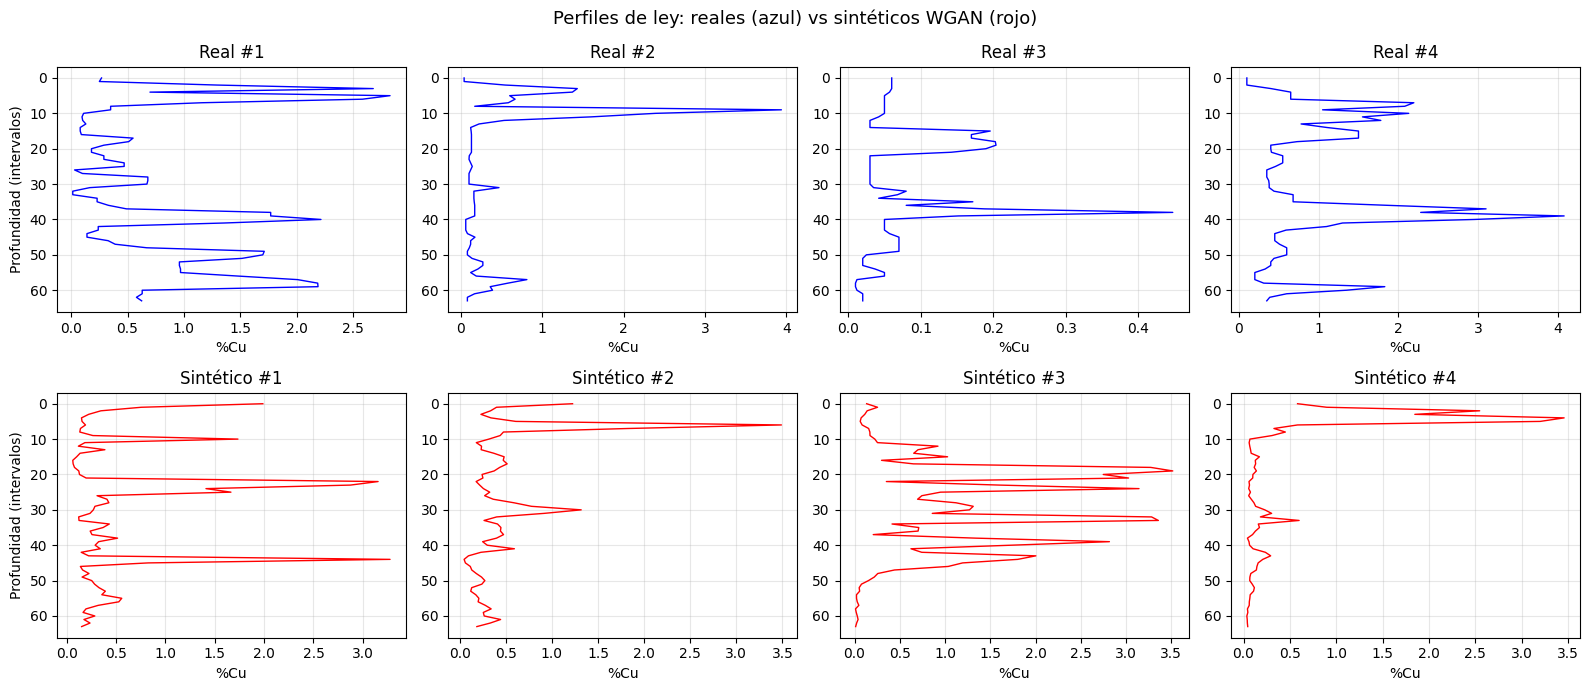

Estadística        Real      Sintético
------------------------------------------
  media            0.384      0.405
  std              0.669      0.667
  p50              0.150      0.177
  p90              0.950      0.951
  max              4.079      4.077


In [32]:
# ==============================================================
# CELDA 14 — Chequeo visual: perfiles reales vs sintéticos
# ==============================================================
# El MMD confirma que la DISTRIBUCIÓN es correcta. Aquí verificamos
# que los perfiles individuales tienen FORMA realista (variabilidad
# en profundidad, no planos ni ruido puro).

# Generar perfiles sintéticos en %Cu real
z = tf.random.normal((len(perfiles), LATENT))
sint_z = de_pm1(generador(z, training=False).numpy().squeeze(-1))   # log+zscore
sint_cut = inverse_target(sint_z)                                    # %Cu real
real_cut = inverse_target(perfiles)                                  # %Cu real

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
prof = np.arange(WINDOW)   # profundidad relativa (intervalos)
for j in range(4):
    axes[0, j].plot(real_cut[np.random.randint(len(real_cut))], prof, 'b-', lw=1)
    axes[0, j].invert_yaxis(); axes[0, j].set_title(f'Real #{j+1}')
    axes[0, j].set_xlabel('%Cu'); axes[0, j].grid(alpha=0.3)
    axes[1, j].plot(sint_cut[np.random.randint(len(sint_cut))], prof, 'r-', lw=1)
    axes[1, j].invert_yaxis(); axes[1, j].set_title(f'Sintético #{j+1}')
    axes[1, j].set_xlabel('%Cu'); axes[1, j].grid(alpha=0.3)
axes[0,0].set_ylabel('Profundidad (intervalos)')
axes[1,0].set_ylabel('Profundidad (intervalos)')
plt.suptitle('Perfiles de ley: reales (azul) vs sintéticos WGAN (rojo)', fontsize=13)
plt.tight_layout(); plt.show()

# Comparación de estadísticas globales (%Cu real)
print("Estadística        Real      Sintético")
print("-"*42)
for nom, f in [('media', np.mean), ('std', np.std),
               ('p50', lambda x: np.percentile(x,50)),
               ('p90', lambda x: np.percentile(x,90)),
               ('max', np.max)]:
    print(f"  {nom:12s}  {f(real_cut.ravel()):8.3f}   {f(sint_cut.ravel()):8.3f}")

Candidatos en huecos (40-120 m del collar real): 4,806
Collares gemelos ubicados: 200
  Distancia media a sondaje real: 118.8 m


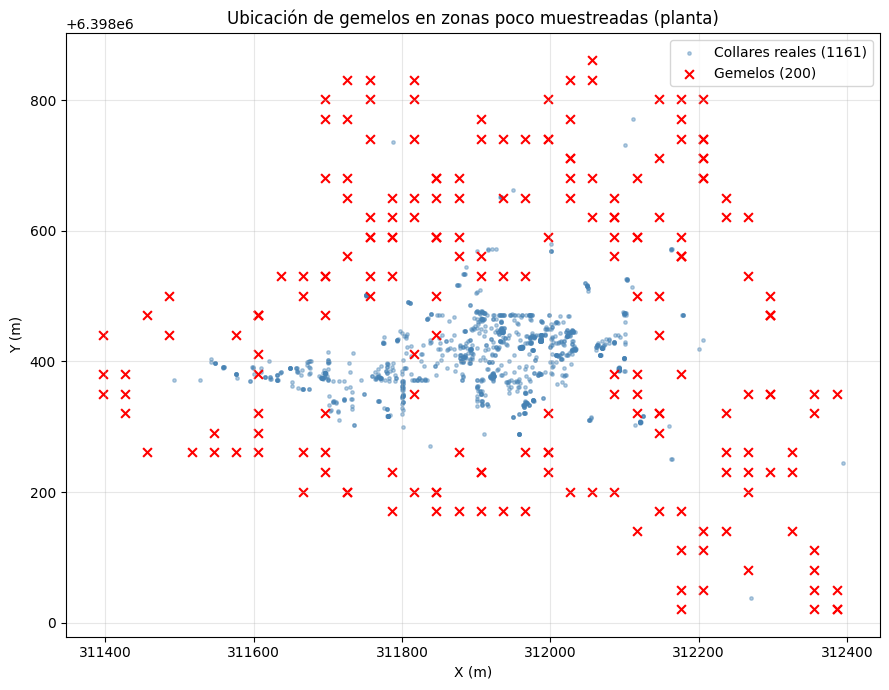

In [33]:
# ==============================================================
# CELDA 15 — Ubicar gemelos en zonas poco muestreadas (Paso 2)
# ==============================================================
# Densificamos donde el yacimiento está mal cubierto. Para cada punto
# candidato en una malla 3D, medimos la distancia al sondaje real más
# cercano; las zonas con MAYOR distancia (huecos) reciben collares
# gemelos. Orientación (DIP/AZIMUT) muestreada de collares reales
# cercanos, para que los gemelos sean geológicamente plausibles.

N_GEMELOS = 200            # nº de sondajes gemelos a generar
PASO_MALLA = 30.0          # m: resolución de la malla de candidatos

# ---- 1. Collares reales (de TRAIN, para no mirar test) -------
collares_reales = df_train_clean.groupby('HOLE-ID').agg(
    X=('X','first'), Y=('Y','first'), Z=('Z','first'),
    DIP=('DIP','first'), AZIMUT=('AZIMUT','first')).reset_index()
coords_reales = collares_reales[['X','Y','Z']].values
tree_collares = cKDTree(coords_reales)

# ---- 2. Malla 3D de candidatos dentro del dominio ------------
xr = np.arange(df_train['X'].min(), df_train['X'].max(), PASO_MALLA)
yr = np.arange(df_train['Y'].min(), df_train['Y'].max(), PASO_MALLA)
zr = np.arange(df_train['Z'].min(), df_train['Z'].max(), PASO_MALLA)
MX, MY, MZ = np.meshgrid(xr, yr, zr, indexing='ij')
candidatos = np.column_stack([MX.ravel(), MY.ravel(), MZ.ravel()])

# ---- 3. Distancia de cada candidato al collar real más cercano
dist_cand, idx_cerca = tree_collares.query(candidatos, k=1)

# Filtrar candidatos: dentro del cuerpo mineralizado (no muy lejos de
# TODO dato) pero en huecos locales (lejos del collar más cercano).
mask_dominio = dist_cand < 120.0        # dentro del yacimiento
mask_hueco   = dist_cand > 40.0         # pero en zona poco muestreada
elegibles = candidatos[mask_dominio & mask_hueco]
dist_eleg = dist_cand[mask_dominio & mask_hueco]
print(f"Candidatos en huecos (40-120 m del collar real): {len(elegibles):,}")

# ---- 4. Elegir los N_GEMELOS huecos más grandes --------------
orden = np.argsort(-dist_eleg)          # mayor distancia primero
sel = elegibles[orden[:N_GEMELOS]]
# orientación: copiar del collar real más cercano a cada gemelo
_, idx_or = tree_collares.query(sel, k=1)
collares_gemelos = pd.DataFrame({
    'X': sel[:,0], 'Y': sel[:,1], 'Z': sel[:,2],
    'DIP':    collares_reales['DIP'].values[idx_or],
    'AZIMUT': collares_reales['AZIMUT'].values[idx_or],
})
print(f"Collares gemelos ubicados: {len(collares_gemelos)}")
print(f"  Distancia media a sondaje real: {dist_eleg[orden[:N_GEMELOS]].mean():.1f} m")

# ---- 5. Visualizar dónde caen los gemelos (planta X-Y) -------
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(coords_reales[:,0], coords_reales[:,1], s=6, c='steelblue',
           alpha=0.4, label=f'Collares reales ({len(coords_reales)})')
ax.scatter(collares_gemelos['X'], collares_gemelos['Y'], s=40, c='red',
           marker='x', label=f'Gemelos ({N_GEMELOS})')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('Ubicación de gemelos en zonas poco muestreadas (planta)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

Candidatos pegados al cuerpo (10-30 m): 1,915
Collares gemelos: 50  dist media a real: 21.7 m


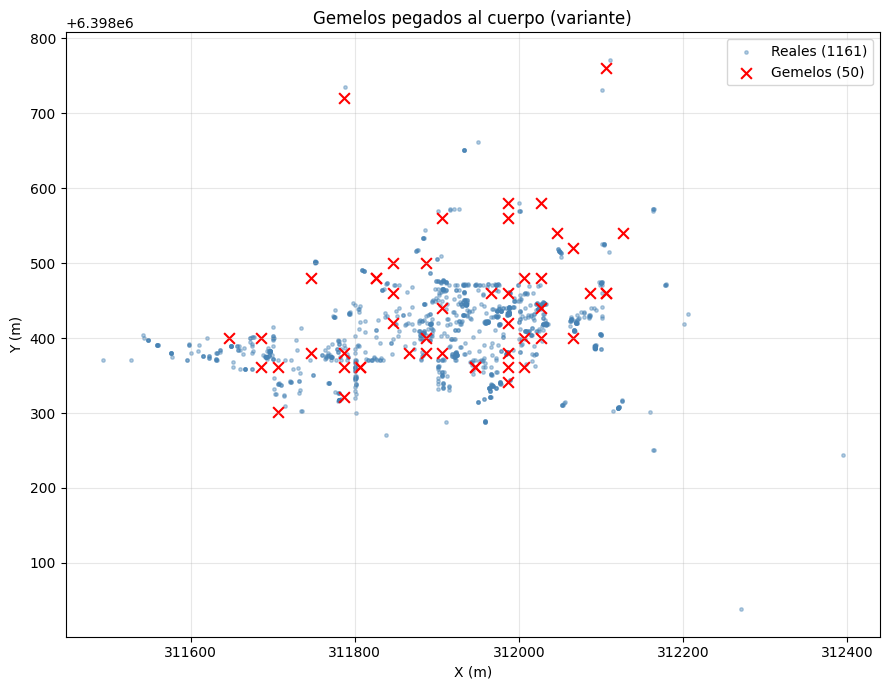

In [34]:
# ==============================================================
# CELDA 15b — Gemelos PEGADOS al cuerpo mineralizado (variante)
# ==============================================================
# Hipótesis: los gemelos periféricos fueron "ruido con estadística
# correcta" porque no tenían datos reales cerca que anclaran su ley.
# Ahora ubicamos POCOS gemelos (50) en la banda bien muestreada, a
# distancia MODERADA de datos reales (10-30 m): cerca hay geología
# real que da contexto, pero aún densifican intersticios.

N_GEMELOS = 50
PASO_MALLA = 20.0          # malla más fina (estamos en la zona densa)

collares_reales = df_train_clean.groupby('HOLE-ID').agg(
    X=('X','first'), Y=('Y','first'), Z=('Z','first'),
    DIP=('DIP','first'), AZIMUT=('AZIMUT','first')).reset_index()
coords_reales = collares_reales[['X','Y','Z']].values
tree_collares = cKDTree(coords_reales)

xr = np.arange(df_train['X'].min(), df_train['X'].max(), PASO_MALLA)
yr = np.arange(df_train['Y'].min(), df_train['Y'].max(), PASO_MALLA)
zr = np.arange(df_train['Z'].min(), df_train['Z'].max(), PASO_MALLA)
MX, MY, MZ = np.meshgrid(xr, yr, zr, indexing='ij')
candidatos = np.column_stack([MX.ravel(), MY.ravel(), MZ.ravel()])
dist_cand, _ = tree_collares.query(candidatos, k=1)

# CAMBIO CLAVE: zona PEGADA al cuerpo (10-30 m), no huecos lejanos (40-120)
mask = (dist_cand > 10.0) & (dist_cand < 30.0)
elegibles = candidatos[mask]
dist_eleg = dist_cand[mask]
print(f"Candidatos pegados al cuerpo (10-30 m): {len(elegibles):,}")

# elegir 50 dispersos: los que están en el rango, muestreados uniformemente
np.random.seed(42)
sel_idx = np.random.choice(len(elegibles), size=min(N_GEMELOS, len(elegibles)), replace=False)
sel = elegibles[sel_idx]
_, idx_or = tree_collares.query(sel, k=1)
collares_gemelos = pd.DataFrame({
    'X': sel[:,0], 'Y': sel[:,1], 'Z': sel[:,2],
    'DIP':    collares_reales['DIP'].values[idx_or],
    'AZIMUT': collares_reales['AZIMUT'].values[idx_or],
})
print(f"Collares gemelos: {len(collares_gemelos)}  "
      f"dist media a real: {dist_eleg[sel_idx].mean():.1f} m")

# visualizar
fig, ax = plt.subplots(figsize=(9,7))
ax.scatter(coords_reales[:,0], coords_reales[:,1], s=6, c='steelblue', alpha=0.4,
           label=f'Reales ({len(coords_reales)})')
ax.scatter(collares_gemelos['X'], collares_gemelos['Y'], s=60, c='red', marker='x',
           label=f'Gemelos ({len(collares_gemelos)})')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('Gemelos pegados al cuerpo (variante)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [35]:
# ==============================================================
# CELDA 16 — Generar trazas de ley + muestrear en puntos (Paso 3)
# ==============================================================
# Cada collar gemelo recibe un perfil sintético del WGAN. Desplegamos
# el perfil a lo largo de la traza (según DIP/AZIMUT) y lo muestreamos
# en puntos individuales -> registros que el Transformer consume.

LARGO_INTERVALO = 1.0      # m por intervalo (mediana real = 1.0 m)

# ---- 1. Generar un perfil sintético por gemelo ---------------
z = tf.random.normal((len(collares_gemelos), LATENT))
perfiles_gem_z = de_pm1(generador(z, training=False).numpy().squeeze(-1))  # (200,64) log+zscore

# ---- 2. Desplegar cada perfil a lo largo de su traza 3D ------
# La traza avanza desde el collar según DIP (buzamiento) y AZIMUT.
# Convención: DIP negativo = hacia abajo; AZIMUT desde el norte (Y+).
def traza_xyz(x0, y0, z0, dip, azimut, n, largo):
    d = np.deg2rad(dip); a = np.deg2rad(azimut)
    # vector unitario de avance de la traza
    dz = np.sin(d)                          # componente vertical
    dh = np.cos(d)                          # componente horizontal
    dx = dh * np.sin(a)                     # este
    dy = dh * np.cos(a)                     # norte
    prof = np.arange(n) * largo             # profundidad a lo largo de la traza
    return (x0 + dx*prof, y0 + dy*prof, z0 + dz*prof, prof)

# ---- 3. Construir los registros punto a punto ----------------
filas = []
for i, col in collares_gemelos.iterrows():
    n = WINDOW
    xs, ys, zs, prof = traza_xyz(col['X'], col['Y'], col['Z'],
                                 col['DIP'], col['AZIMUT'], n, LARGO_INTERVALO)
    cut_z = perfiles_gem_z[i]                         # ley en log+zscore
    cut_real = inverse_target(cut_z)                  # %Cu real
    # litología: la del punto real más cercano a cada punto del gemelo
    for k in range(n):
        filas.append({
            'HOLE-ID': f'GEM{i:04d}',
            'X': xs[k], 'Y': ys[k], 'Z': zs[k],
            'DIP': col['DIP'], 'AZIMUT': col['AZIMUT'],
            'FROM': prof[k], 'CUT': cut_real[k],
        })
df_gemelos = pd.DataFrame(filas)

# ---- 4. Asignar litología por vecino real más cercano --------
_, idx_lito = cKDTree(df_train_clean[COORDS].values).query(
    df_gemelos[COORDS].values, k=1)
df_gemelos['LITOLOGIA'] = df_train_clean[FEATURE_CAT].values[idx_lito]

print(f"Sondajes gemelos: {df_gemelos['HOLE-ID'].nunique()}")
print(f"Puntos gemelos totales: {len(df_gemelos):,}")
print(f"CUT gemelos (%Cu): media={df_gemelos['CUT'].mean():.3f}  "
      f"std={df_gemelos['CUT'].std():.3f}  max={df_gemelos['CUT'].max():.3f}")
print(f"CUT real train:    media={df_train['CUT'].mean():.3f}  "
      f"std={df_train['CUT'].std():.3f}  max={df_train['CUT'].max():.3f}")

# ---- 5. Verificar que los gemelos caen dentro del dominio Z --
print(f"\nRango Z gemelos: [{df_gemelos['Z'].min():.0f}, {df_gemelos['Z'].max():.0f}] m")
print(f"Rango Z real:    [{df_train['Z'].min():.0f}, {df_train['Z'].max():.0f}] m")

Sondajes gemelos: 50
Puntos gemelos totales: 3,200
CUT gemelos (%Cu): media=0.404  std=0.719  max=4.074
CUT real train:    media=0.411  std=0.690  max=4.079

Rango Z gemelos: [701, 1042] m
Rango Z real:    [662, 1171] m


In [36]:
# ==============================================================
# CELDA 16b — Recortar gemelos al dominio Z real (conservador)
# ==============================================================
# Eliminamos puntos gemelos fuera del rango Z de los datos reales:
# son extrapolación pura (el WGAN nunca vio leyes a esa profundidad).
# También recortamos en X,Y por si algún gemelo inclinado se saliera.

z_min, z_max = df_train['Z'].min(), df_train['Z'].max()
x_min, x_max = df_train['X'].min(), df_train['X'].max()
y_min, y_max = df_train['Y'].min(), df_train['Y'].max()

n_antes = len(df_gemelos)
dentro = (
    (df_gemelos['Z'] >= z_min) & (df_gemelos['Z'] <= z_max) &
    (df_gemelos['X'] >= x_min) & (df_gemelos['X'] <= x_max) &
    (df_gemelos['Y'] >= y_min) & (df_gemelos['Y'] <= y_max)
)
df_gemelos = df_gemelos[dentro].reset_index(drop=True)

# Descartar gemelos que quedaron demasiado cortos tras el recorte
# (una traza con <16 puntos ya no es un sondaje útil)
largos_gem = df_gemelos.groupby('HOLE-ID').size()
holes_validos = largos_gem[largos_gem >= 16].index
df_gemelos = df_gemelos[df_gemelos['HOLE-ID'].isin(holes_validos)].reset_index(drop=True)

print(f"Puntos gemelos: {n_antes:,} -> {len(df_gemelos):,} "
      f"(recortados {n_antes-len(df_gemelos):,})")
print(f"Sondajes gemelos válidos (>=16 pts): {df_gemelos['HOLE-ID'].nunique()}")
print(f"Rango Z gemelos ahora: [{df_gemelos['Z'].min():.0f}, {df_gemelos['Z'].max():.0f}] m "
      f"(real: [{z_min:.0f}, {z_max:.0f}])")
print(f"CUT gemelos: media={df_gemelos['CUT'].mean():.3f}  std={df_gemelos['CUT'].std():.3f}")

Puntos gemelos: 3,200 -> 3,200 (recortados 0)
Sondajes gemelos válidos (>=16 pts): 50
Rango Z gemelos ahora: [701, 1042] m (real: [662, 1171])
CUT gemelos: media=0.404  std=0.719


In [37]:
# ==============================================================
# CELDA 17 — Re-entrenar Transformer con gemelos (train real + gemelos)
# ==============================================================
# Protocolo justo: MISMO test real, mismo modelo, mismos hiperparámetros.
# Lo único que cambia: el train (y el soporte de vecinos) incluye gemelos.
#
# DECISIÓN CLAVE de soporte de vecinos para TEST:
#   Los puntos de test buscan vecinos en train_real + gemelos. Esto es
#   lo que queremos medir: ¿ayuda tener gemelos en la periferia como
#   soporte de interpolación? El test sigue siendo 100% real (verdad
#   de terreno intacta); solo cambia de DÓNDE saca información.

# ---- 1. Preparar df de gemelos como los reales (escalar features) --
df_gem = df_gemelos.copy()
df_gem['FROM_REAL'] = df_gem['FROM'].values
df_gem[FEATURES_NUM] = scaler.transform(df_gem[FEATURES_NUM])   # mismo scaler de train
df_gem[TARGET] = transform_target(df_gem[TARGET].values)        # mismo transform

# ---- 2. Soporte aumentado = train real + gemelos -------------
df_train_aug = pd.concat([df_train_s, df_gem], ignore_index=True)
print(f"Soporte aumentado: {len(df_train_s):,} reales + {len(df_gem):,} gemelos "
      f"= {len(df_train_aug):,}")

# ---- 3. Reconstruir vecindarios con soporte aumentado --------
# Train: puntos reales + gemelos, vecinos del soporte aumentado (R_MIN anti-leak)
# Test:  puntos reales (sin cambio), vecinos del soporte aumentado
data_train_aug = construir_vecindarios(df_train_aug, df_train_aug, exclude_self_radius=R_MIN)
data_test_aug  = construir_vecindarios(df_test_s,    df_train_aug, exclude_self_radius=0.0)
# val se mantiene con soporte aumentado también, para early stopping coherente
data_val_aug   = construir_vecindarios(df_val_s,     df_train_aug, exclude_self_radius=0.0)

# ---- 4. Re-instanciar el modelo (mismos hiperparámetros) -----
modelo_aug = construir_transformer_espacial(N_FEAT, N_LITO, K_VECINOS)
modelo_aug.compile(optimizer=keras.optimizers.Adam(5e-4), loss='mae', metrics=['mae'])

callbacks_aug = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, min_lr=1e-5, verbose=1),
    VigilarVarRatio(to_inputs(data_val_aug), data_val_aug['y'], cada=3),
]

print("\nRe-entrenando Transformer con gemelos...\n")
hist_aug = modelo_aug.fit(
    to_inputs(data_train_aug), data_train_aug['y'],
    validation_data=(to_inputs(data_val_aug), data_val_aug['y']),
    epochs=100, batch_size=256, callbacks=callbacks_aug, verbose=2)

# ---- 5. Evaluar en TEST REAL (verdad intacta) ----------------
pred_z_aug = modelo_aug.predict(to_inputs(data_test_aug), verbose=0).ravel()
tr_pred_aug = inverse_target(pred_z_aug)
y_real = df_test[TARGET].values.astype(float)
res_tr_aug = metricas_basicas(y_real, tr_pred_aug, "Transformer + gemelos")

modelo_aug.save(RUTA_OUT + 'transformer_gemelos.keras')
print("\n✓ Re-entrenamiento con gemelos completado.")

Soporte aumentado: 86,047 reales + 3,200 gemelos = 89,247

Re-entrenando Transformer con gemelos...

Epoch 1/100
349/349 - 49s - 140ms/step - loss: 0.5643 - mae: 0.5643 - val_loss: 0.4978 - val_mae: 0.4978 - learning_rate: 5.0000e-04
Epoch 2/100
349/349 - 38s - 109ms/step - loss: 0.4656 - mae: 0.4656 - val_loss: 0.4952 - val_mae: 0.4952 - learning_rate: 5.0000e-04
Epoch 3/100
    [ep 3] val VarRatio=0.195  Spearman=0.373
349/349 - 47s - 136ms/step - loss: 0.4555 - mae: 0.4555 - val_loss: 0.4996 - val_mae: 0.4996 - learning_rate: 5.0000e-04
Epoch 4/100
349/349 - 37s - 107ms/step - loss: 0.4495 - mae: 0.4495 - val_loss: 0.5026 - val_mae: 0.5026 - learning_rate: 5.0000e-04
Epoch 5/100
349/349 - 37s - 105ms/step - loss: 0.4456 - mae: 0.4456 - val_loss: 0.5049 - val_mae: 0.5049 - learning_rate: 5.0000e-04
Epoch 6/100
    [ep 6] val VarRatio=0.247  Spearman=0.374
349/349 - 42s - 120ms/step - loss: 0.4412 - mae: 0.4412 - val_loss: 0.5096 - val_mae: 0.5096 - learning_rate: 5.0000e-04
Epoch 7/1

In [38]:
# ==============================================================
# CELDA PARCHE-1 — Fix EdgeConvAgg + semilla TF + filtro anti-aislados
# ==============================================================
# BUG ORIGINAL: en la agregación max, tf.where(m>0, h, -1e9) devolvía
# -1e9 para puntos SIN NINGÚN vecino válido (posible solo en train,
# donde R_MIN=3 m excluye vecinos del mismo abanico). Ese -1e9 pasaba
# por las capas densas y explotaba la salida -> la loss de train
# aparecía en cientos de miles mientras val_loss era normal (~0.5).
# El early stopping salvó al modelo, pero la loss de train reportada
# estaba contaminada y esos puntos metían gradientes destructivos.
#
# FIX (2 capas de defensa):
#  (a) el max se anula (vector 0) para puntos sin vecinos válidos;
#  (b) los puntos de train sin vecinos se FILTRAN antes de entrenar
#      (un punto sin soporte no define una tarea de interpolación).
#
# Además: semilla global de TF (la CELDA 1 solo fijaba numpy; los pesos
# y el tf.random.normal de los gemelos no eran reproducibles).

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(SEED)   # numpy + python + tensorflow

class EdgeConvAgg(layers.Layer):
    """EdgeConv: MLP por arista + agregación enmascarada (mean+max).
    v2: max seguro — puntos sin vecinos válidos devuelven 0, no -1e9."""
    def __init__(self, units, dropout=0.1, **kw):
        super().__init__(**kw)
        self.mlp = keras.Sequential([
            layers.Dense(units, activation='gelu'),
            layers.Dropout(dropout),
            layers.Dense(units, activation='gelu'),
        ])
    def call(self, x_obj, x_vec, delta, cut_vec, mask):
        # x_obj:(B,F)  x_vec:(B,K,F)  delta:(B,K,3)  cut_vec:(B,K,1)  mask:(B,K)
        K = tf.shape(x_vec)[1]
        xo   = tf.repeat(x_obj[:, None, :], K, axis=1)          # (B,K,F)
        edge = tf.concat([xo, x_vec - xo, delta, cut_vec], axis=-1)
        h = self.mlp(edge)                                      # (B,K,units)
        m = mask[:, :, None]                                    # (B,K,1)
        h = h * m
        # media enmascarada
        suma = tf.reduce_sum(h, axis=1)
        cnt  = tf.maximum(tf.reduce_sum(m, axis=1), 1.0)
        mean = suma / cnt
        # max enmascarado SEGURO
        h_msk = tf.where(m > 0, h, tf.fill(tf.shape(h),
                                           tf.constant(-1e9, tf.float32)))
        mx = tf.reduce_max(h_msk, axis=1)                       # (B,units)
        tiene_vec = tf.cast(tf.reduce_sum(m, axis=1) > 0, tf.float32)  # (B,1)
        mx = mx * tiene_vec         # <- FIX: sin vecinos => 0, no -1e9
        return tf.concat([mean, mx], axis=-1)                   # (B,2*units)

def filtrar_sin_vecinos(d, nombre=''):
    """Elimina del dict de vecindarios los puntos con mask todo-cero."""
    ok = d['mask'].sum(axis=1) > 0
    n_bad = int((~ok).sum())
    if n_bad == 0:
        print(f"[{nombre}] sin puntos aislados — no se filtra nada.")
        return d
    idx = np.where(ok)[0]
    d2 = {}
    for k, v in d.items():
        if isinstance(v, np.ndarray):
            d2[k] = v[ok]
        else:                         # 'meta' es lista de tuplas
            d2[k] = [v[i] for i in idx]
    print(f"[{nombre}] filtrados {n_bad} puntos sin vecinos válidos "
          f"({100*n_bad/len(ok):.3f}% de {len(ok):,}).")
    return d2

# ---- Diagnóstico: ¿cuántos puntos aislados hay realmente? ----
for nom, d in [('train', data_train), ('val', data_val), ('test', data_test),
               ('train_aug', data_train_aug)]:
    n0 = int((d['mask'].sum(axis=1) == 0).sum())
    print(f"  {nom:10s}: {n0:>5} puntos con 0 vecinos válidos de {len(d['y']):,}")

data_train_f     = filtrar_sin_vecinos(data_train,     'train')
data_train_aug_f = filtrar_sin_vecinos(data_train_aug, 'train_aug')
print("\n✓ EdgeConvAgg v2 definida, semilla TF fijada, trains filtrados.")


  train     :   162 puntos con 0 vecinos válidos de 86,047
  val       :     0 puntos con 0 vecinos válidos de 18,440
  test      :     0 puntos con 0 vecinos válidos de 18,439
  train_aug :   162 puntos con 0 vecinos válidos de 89,247
[train] filtrados 162 puntos sin vecinos válidos (0.188% de 86,047).
[train_aug] filtrados 162 puntos sin vecinos válidos (0.182% de 89,247).

✓ EdgeConvAgg v2 definida, semilla TF fijada, trains filtrados.


In [39]:
# ==============================================================
# CELDA PARCHE-2 — Re-entrenar GNN EdgeConv corregido (datos reales)
# ==============================================================
# Mismos hiperparámetros que la CELDA 10 original. Con el fix, la loss
# de train debe quedar en la MISMA escala que val (~0.4-0.6). Si vuelve
# a explotar, algo quedó sin redefinir (reiniciar runtime y re-correr).
# NOTA: construir_gnn usa EdgeConvAgg del namespace global, por lo que
# basta re-instanciar (no hay que repegar el constructor).

gnn = construir_gnn(N_FEAT, N_LITO, K_VECINOS)
gnn.compile(optimizer=keras.optimizers.Adam(5e-4), loss='mae', metrics=['mae'])
print(f"GNN EdgeConv v2: {gnn.count_params():,} parámetros")

callbacks_gnn = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, min_lr=1e-5, verbose=1),
    VigilarVarRatio(to_inputs(data_val), data_val['y'], cada=3),
]

print("\nEntrenando GNN EdgeConv v2 (fix)...\n")
hist_gnn = gnn.fit(
    to_inputs(data_train_f), data_train_f['y'],
    validation_data=(to_inputs(data_val), data_val['y']),
    epochs=100, batch_size=256, callbacks=callbacks_gnn, verbose=2)

# ---- Evaluación en test real ---------------------------------
y_real   = df_test[TARGET].values.astype(float)
gnn_pred = inverse_target(gnn.predict(to_inputs(data_test), verbose=0).ravel())
res_gnn  = metricas_basicas(y_real, gnn_pred, "GNN EdgeConv (fix)")

gnn.save(RUTA_OUT + 'gnn_edgeconv_v2.keras')
import pickle, json
pickle.dump(hist_gnn.history, open(RUTA_OUT + 'history_gnn_v2.pkl', 'wb'))
np.save(RUTA_OUT + 'gnn_pred_test_v2.npy', gnn_pred)
json.dump(res_gnn, open(RUTA_OUT + 'res_gnn_v2.json', 'w'))
print("\n✓ GNN v2 entrenado, evaluado y guardado.")

GNN EdgeConv v2: 19,161 parámetros

Entrenando GNN EdgeConv v2 (fix)...

Epoch 1/100
336/336 - 21s - 63ms/step - loss: 0.5178 - mae: 0.5178 - val_loss: 0.5276 - val_mae: 0.5276 - learning_rate: 5.0000e-04
Epoch 2/100
336/336 - 17s - 49ms/step - loss: 0.4639 - mae: 0.4639 - val_loss: 0.5163 - val_mae: 0.5163 - learning_rate: 5.0000e-04
Epoch 3/100
    [ep 3] val VarRatio=0.114  Spearman=0.351
336/336 - 21s - 61ms/step - loss: 0.4523 - mae: 0.4523 - val_loss: 0.4993 - val_mae: 0.4993 - learning_rate: 5.0000e-04
Epoch 4/100
336/336 - 17s - 50ms/step - loss: 0.4434 - mae: 0.4434 - val_loss: 0.5027 - val_mae: 0.5027 - learning_rate: 5.0000e-04
Epoch 5/100
336/336 - 17s - 49ms/step - loss: 0.4376 - mae: 0.4376 - val_loss: 0.4866 - val_mae: 0.4866 - learning_rate: 5.0000e-04
Epoch 6/100
    [ep 6] val VarRatio=0.102  Spearman=0.401
336/336 - 22s - 64ms/step - loss: 0.4340 - mae: 0.4340 - val_loss: 0.4811 - val_mae: 0.4811 - learning_rate: 5.0000e-04
Epoch 7/100
336/336 - 16s - 49ms/step - los

In [40]:
# ==============================================================
# CELDA PARCHE-3 — Baselines triviales (contexto para la tabla final)
# ==============================================================
# Con split espacial honesto hay shift de dominio (test = otra zona,
# leyes más bajas). Estos baselines exponen cuánto de MAE/RMSE se
# explica solo por ese shift. Un modelo solo "agrega valor" donde una
# constante no puede competir: Spearman, MedAE, DTW, Moran's I.

from scipy.spatial import cKDTree as _KDT

y_real = df_test[TARGET].values.astype(float)
cut_tr_real = df_train[TARGET].values.astype(float)

# (a) constante = mediana de train (óptimo teórico de MAE si no hay info)
pred_med = np.full(len(y_real), np.median(cut_tr_real))
res_cmed = metricas_basicas(y_real, pred_med, "Const. mediana(train)")

# (b) constante = expm1(media de log1p) — centro del espacio z-log usado
pred_logm = np.full(len(y_real), np.expm1(np.log1p(cut_tr_real).mean()))
res_clog = metricas_basicas(y_real, pred_logm, "Const. expm1(logmean)")

# (c) IDW k=24, p=2 — determinista simple, mismos vecinos que los modelos
_tree = _KDT(df_train[COORDS].values)
_dk, _ik = _tree.query(df_test[COORDS].values, k=K_VECINOS)
_w = 1.0 / np.maximum(_dk, 1e-6) ** 2
_w = _w / _w.sum(axis=1, keepdims=True)
pred_idw = (_w * cut_tr_real[_ik]).sum(axis=1)
res_idw = metricas_basicas(y_real, pred_idw, f"IDW k={K_VECINOS} p=2")

json.dump({'const_mediana': res_cmed, 'const_logmean': res_clog,
           'idw': res_idw}, open(RUTA_OUT + 'res_baselines_triviales.json', 'w'))
print("\n✓ Baselines triviales calculados y guardados.")



Const. mediana(train) — test espacial (%Cu real)
  MAE      : 0.2328
  RMSE     : 0.5243
  R²       : -0.0424
  MedAE    : 0.1200
  SMAPE    : 84.13%
  Spearman : nan   (ordenamiento de leyes)
  VarRatio : 0.0000   (var_pred/var_real; ~1 = sin aplanar)

Const. expm1(logmean) — test espacial (%Cu real)
  MAE      : 0.2911
  RMSE     : 0.5144
  R²       : -0.0037
  MedAE    : 0.2170
  SMAPE    : 97.68%
  Spearman : nan   (ordenamiento de leyes)
  VarRatio : 0.0000   (var_pred/var_real; ~1 = sin aplanar)

IDW k=24 p=2 — test espacial (%Cu real)
  MAE      : 0.2698
  RMSE     : 0.5358
  R²       : -0.0889
  MedAE    : 0.1180
  SMAPE    : 84.59%
  Spearman : 0.2779   (ordenamiento de leyes)
  VarRatio : 0.2724   (var_pred/var_real; ~1 = sin aplanar)

✓ Baselines triviales calculados y guardados.


In [41]:
# ==============================================================
# CELDA PARCHE-4 — IK + gemelos (mismo protocolo, soporte aumentado)
# ==============================================================
# Protocolo idéntico a la CELDA 5: mismos umbrales-percentil, mismo
# variograma exponencial, mismos 40 vecinos, misma regularización,
# misma isotónica + integral de supervivencia. Lo ÚNICO que cambia:
# el soporte incluye los gemelos (en %Cu REAL, como exige el IK).
# Checkpoint NUEVO para no reanudar del IK real por accidente.

from pykrige.ok3d import OrdinaryKriging3D
from scipy.spatial.distance import cdist
from scipy.linalg import solve
from sklearn.isotonic import IsotonicRegression
import time, os

K_UMBRALES   = 7
N_VARIOGRAMA = 2000
N_VECINOS_IK = 40

def vario_exp(h, psill, rng, nug):
    return psill * (1.0 - np.exp(-h / rng)) + nug

def correr_ik(df_soporte, nombre, ckpt_name, seed=42):
    """IK ordinario local con soporte arbitrario (en %Cu REAL).
    Evalúa siempre sobre df_test. Devuelve (pred, res_dict)."""
    pts_sup = df_soporte[COORDS].values
    cut_sup = df_soporte[TARGET].values.astype(np.float64)
    pts_te  = df_test[COORDS].values
    cut_te  = df_test[TARGET].values.astype(np.float64)
    n_te    = len(pts_te)

    umbrales = np.percentile(cut_sup, np.linspace(10, 90, K_UMBRALES))
    print(f"[{nombre}] soporte={len(pts_sup):,} pts | umbrales:",
          np.round(umbrales, 4))

    rng_np  = np.random.RandomState(seed)
    idx_v   = rng_np.choice(len(pts_sup),
                            size=min(N_VARIOGRAMA, len(pts_sup)), replace=False)
    sub_pts, sub_cut = pts_sup[idx_v], cut_sup[idx_v]

    tree = cKDTree(pts_sup)
    _, vec_idx = tree.query(pts_te, k=N_VECINOS_IK)

    ckpt = RUTA_OUT + ckpt_name
    F_hat = np.zeros((n_te, K_UMBRALES)); k_start = 0
    if os.path.exists(ckpt):
        F_hat, k_done = pickle.load(open(ckpt, 'rb'))
        k_start = k_done + 1
        print(f"  Reanudando desde umbral {k_start+1}")

    for k in range(k_start, K_UMBRALES):
        t_k = umbrales[k]; t0 = time.time()
        ind_sub = (sub_cut <= t_k).astype(float)
        try:
            ok = OrdinaryKriging3D(sub_pts[:,0], sub_pts[:,1], sub_pts[:,2],
                                   ind_sub, variogram_model='exponential',
                                   nlags=15, weight=True, verbose=False,
                                   enable_plotting=False)
            psill, rngv, nug = ok.variogram_model_parameters
        except Exception as e:
            print(f"  Umbral {k+1}: variograma falló ({e}) -> proporción global")
            F_hat[:, k] = ind_sub.mean(); continue

        ind_full = (cut_sup <= t_k).astype(float)
        probs = np.zeros(n_te); n_sing = 0
        for i in range(n_te):
            idx = vec_idx[i]
            pd_, vd_ = pts_sup[idx], ind_full[idx]; n = len(idx)
            G = vario_exp(cdist(pd_, pd_), psill, rngv, nug)
            A = np.zeros((n+1, n+1)); A[:n,:n] = G
            A[:n,n] = 1.0; A[n,:n] = 1.0
            A[:n,:n] += np.eye(n) * (psill * 1e-4 + 1e-8)
            b = np.zeros(n+1)
            b[:n] = vario_exp(cdist([pts_te[i]], pd_)[0], psill, rngv, nug)
            b[n] = 1.0
            try:
                w = solve(A, b, assume_a='sym')
                p = w[:n] @ vd_
                if not np.isfinite(p) or abs(p) > 5.0:
                    p = vd_.mean(); n_sing += 1
            except Exception:
                p = vd_.mean(); n_sing += 1
            probs[i] = p
        F_hat[:, k] = np.clip(probs, 0.0, 1.0)
        pickle.dump((F_hat, k), open(ckpt, 'wb'))
        print(f"  Umbral {k+1}/{K_UMBRALES}  t={t_k:.4f}  "
              f"P̄={probs.mean():.3f}  singulares={n_sing}  "
              f"({time.time()-t0:.0f}s) ✓")

    ir = IsotonicRegression(increasing=True, out_of_bounds='clip')
    for i in range(n_te):
        F_hat[i] = ir.fit_transform(np.arange(K_UMBRALES), F_hat[i])

    cmin, cmax = 0.0, np.quantile(cut_sup, 0.99)
    t_ext  = np.concatenate([[cmin], umbrales, [cmax]])
    F_ext  = np.hstack([np.zeros((n_te,1)), F_hat, np.ones((n_te,1))])
    S_mid  = 1 - 0.5*(F_ext[:,:-1] + F_ext[:,1:])
    pred   = np.clip((S_mid * np.diff(t_ext)).sum(axis=1), 0, None)

    res = metricas_basicas(cut_te, pred, nombre)
    return pred, res

# ---- Soporte aumentado: train real + gemelos (%Cu real) -------
# df_gemelos ya tiene CUT en %Cu real (se generó con inverse_target).
assert df_gemelos[TARGET].max() > 0.5, "df_gemelos parece no estar en %Cu real"
df_sup_ikgem = pd.concat([
    df_train[COORDS + [TARGET]],
    df_gemelos[COORDS + [TARGET]],
], ignore_index=True)

ikgem_pred, res_ik_gem = correr_ik(df_sup_ikgem, "IK + gemelos",
                                   'F_hat_ikgem_ckpt.pkl')

np.save(RUTA_OUT + 'ikgem_pred_test.npy', ikgem_pred)
json.dump(res_ik_gem, open(RUTA_OUT + 'res_ik_gem.json', 'w'))
print("\n✓ IK + gemelos completado y guardado.")


[IK + gemelos] soporte=89,247 pts | umbrales: [0.03   0.07   0.1115 0.177  0.25   0.42   1.0352]
  Umbral 1/7  t=0.0300  P̄=0.193  singulares=0  (211s) ✓
  Umbral 2/7  t=0.0700  P̄=0.288  singulares=0  (209s) ✓
  Umbral 3/7  t=0.1115  P̄=0.392  singulares=0  (211s) ✓
  Umbral 4/7  t=0.1770  P̄=0.535  singulares=0  (205s) ✓
  Umbral 5/7  t=0.2500  P̄=0.679  singulares=0  (244s) ✓
  Umbral 6/7  t=0.4200  P̄=0.807  singulares=0  (238s) ✓
  Umbral 7/7  t=1.0352  P̄=0.929  singulares=0  (228s) ✓

IK + gemelos — test espacial (%Cu real)
  MAE      : 0.3373
  RMSE     : 0.5671
  R²       : -0.2198
  MedAE    : 0.1870
  SMAPE    : 95.74%
  Spearman : 0.2010   (ordenamiento de leyes)
  VarRatio : 0.3943   (var_pred/var_real; ~1 = sin aplanar)

✓ IK + gemelos completado y guardado.


In [42]:
# ==============================================================
# CELDA PARCHE-5 — GNN + gemelos (mismo protocolo que Transf+gemelos)
# ==============================================================
# Reusa data_train_aug / data_val_aug / data_test_aug construidos en la
# CELDA 17 (soporte de vecinos = train real + gemelos; test 100% real).
# Mismos hiperparámetros que el GNN v2. Train filtrado de aislados.

gnn_aug = construir_gnn(N_FEAT, N_LITO, K_VECINOS)
gnn_aug.compile(optimizer=keras.optimizers.Adam(5e-4), loss='mae', metrics=['mae'])

callbacks_gnn_aug = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, min_lr=1e-5, verbose=1),
    VigilarVarRatio(to_inputs(data_val_aug), data_val_aug['y'], cada=3),
]

print("Entrenando GNN + gemelos...\n")
hist_gnn_aug = gnn_aug.fit(
    to_inputs(data_train_aug_f), data_train_aug_f['y'],
    validation_data=(to_inputs(data_val_aug), data_val_aug['y']),
    epochs=100, batch_size=256, callbacks=callbacks_gnn_aug, verbose=2)

gnngem_pred = inverse_target(
    gnn_aug.predict(to_inputs(data_test_aug), verbose=0).ravel())
res_gnn_gem = metricas_basicas(y_real, gnngem_pred, "GNN + gemelos")

gnn_aug.save(RUTA_OUT + 'gnn_gemelos.keras')
np.save(RUTA_OUT + 'gnngem_pred_test.npy', gnngem_pred)
json.dump(res_gnn_gem, open(RUTA_OUT + 'res_gnn_gem.json', 'w'))
print("\n✓ GNN + gemelos completado y guardado.")


Entrenando GNN + gemelos...

Epoch 1/100
348/348 - 20s - 58ms/step - loss: 0.5215 - mae: 0.5215 - val_loss: 0.5230 - val_mae: 0.5230 - learning_rate: 5.0000e-04
Epoch 2/100
348/348 - 17s - 50ms/step - loss: 0.4681 - mae: 0.4681 - val_loss: 0.4912 - val_mae: 0.4912 - learning_rate: 5.0000e-04
Epoch 3/100
    [ep 3] val VarRatio=0.103  Spearman=0.371
348/348 - 23s - 65ms/step - loss: 0.4540 - mae: 0.4540 - val_loss: 0.4941 - val_mae: 0.4941 - learning_rate: 5.0000e-04
Epoch 4/100
348/348 - 18s - 51ms/step - loss: 0.4457 - mae: 0.4457 - val_loss: 0.4901 - val_mae: 0.4901 - learning_rate: 5.0000e-04
Epoch 5/100
348/348 - 18s - 51ms/step - loss: 0.4384 - mae: 0.4384 - val_loss: 0.4876 - val_mae: 0.4876 - learning_rate: 5.0000e-04
Epoch 6/100
    [ep 6] val VarRatio=0.078  Spearman=0.402
348/348 - 19s - 55ms/step - loss: 0.4333 - mae: 0.4333 - val_loss: 0.4831 - val_mae: 0.4831 - learning_rate: 5.0000e-04
Epoch 7/100
348/348 - 19s - 54ms/step - loss: 0.4295 - mae: 0.4295 - val_loss: 0.4807 -

In [43]:
# ==============================================================
# CELDA PARCHE-6 — Tabla final consolidada (modelos + gemelos + triviales)
# ==============================================================
# Deja lista la tabla del informe: efecto de los gemelos sobre LOS TRES
# modelos + baselines triviales como piso de referencia.

import pandas as pd

# Requiere en memoria: tr_pred (CELDA 8) y tr_pred_aug (CELDA 17).
# ik_pred se recarga de disco si hace falta.
try:
    ik_pred
except NameError:
    ik_pred = np.load(RUTA_OUT + 'ik_pred_test.npy')

y_real = df_test[TARGET].values.astype(float)

filas = []
for nom, pred in [
    ('Const. mediana(train)', pred_med),
    (f'IDW k={K_VECINOS}',    pred_idw),
    ('IK',                    ik_pred),
    ('IK + gemelos',          ikgem_pred),
    ('GNN (fix)',             gnn_pred),
    ('GNN + gemelos',         gnngem_pred),
    ('Transformer',           tr_pred),
    ('Transformer + gemelos', tr_pred_aug),
]:
    filas.append(metricas_basicas(y_real, pred, nom, verbose=False))

tabla_full = pd.DataFrame(filas).set_index('modelo')
print(tabla_full.round(4).to_string())
tabla_full.to_csv(RUTA_OUT + 'tabla_final_completa.csv')

# ---- Delta por gemelos (la pregunta del proyecto) -------------
print("\nEfecto de los gemelos (Δ = con_gemelos - sin_gemelos):")
pares = [('IK', 'IK + gemelos'), ('GNN (fix)', 'GNN + gemelos'),
         ('Transformer', 'Transformer + gemelos')]
for base, aug in pares:
    for m in ['MAE', 'RMSE', 'MedAE', 'Spearman', 'VarRatio']:
        d = tabla_full.loc[aug, m] - tabla_full.loc[base, m]
        mejor = (d < 0) if m in ('MAE', 'RMSE', 'MedAE') else (d > 0)
        print(f"  {base:12s} -> {m:9s} Δ={d:+.4f} {'✓ mejora' if mejor else '✗ empeora'}")
    print()

print("✓ tabla_final_completa.csv guardada — lista para el informe.")


                          MAE    RMSE      R2   MedAE    SMAPE  Spearman  VarRatio
modelo                                                                            
Const. mediana(train)  0.2328  0.5243 -0.0424  0.1200  84.1290       NaN    0.0000
IDW k=24               0.2698  0.5358 -0.0889  0.1180  84.5902    0.2779    0.2724
IK                     0.2997  0.5511 -0.1521  0.1457  89.5084    0.2644    0.3558
IK + gemelos           0.3373  0.5671 -0.2198  0.1870  95.7356    0.2010    0.3943
GNN (fix)              0.2199  0.5240 -0.0414  0.0862  81.0765    0.3369    0.0408
GNN + gemelos          0.2241  0.5220 -0.0336  0.0962  83.3726    0.2883    0.0352
Transformer            0.2309  0.5269 -0.0528  0.0894  79.5282    0.2866    0.1233
Transformer + gemelos  0.2503  0.5262 -0.0501  0.1076  84.3280    0.2036    0.1543

Efecto de los gemelos (Δ = con_gemelos - sin_gemelos):
  IK           -> MAE       Δ=+0.0376 ✗ empeora
  IK           -> RMSE      Δ=+0.0160 ✗ empeora
  IK           -> 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.9/808.9 kB 12.4 MB/s eta 0:00:00
Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



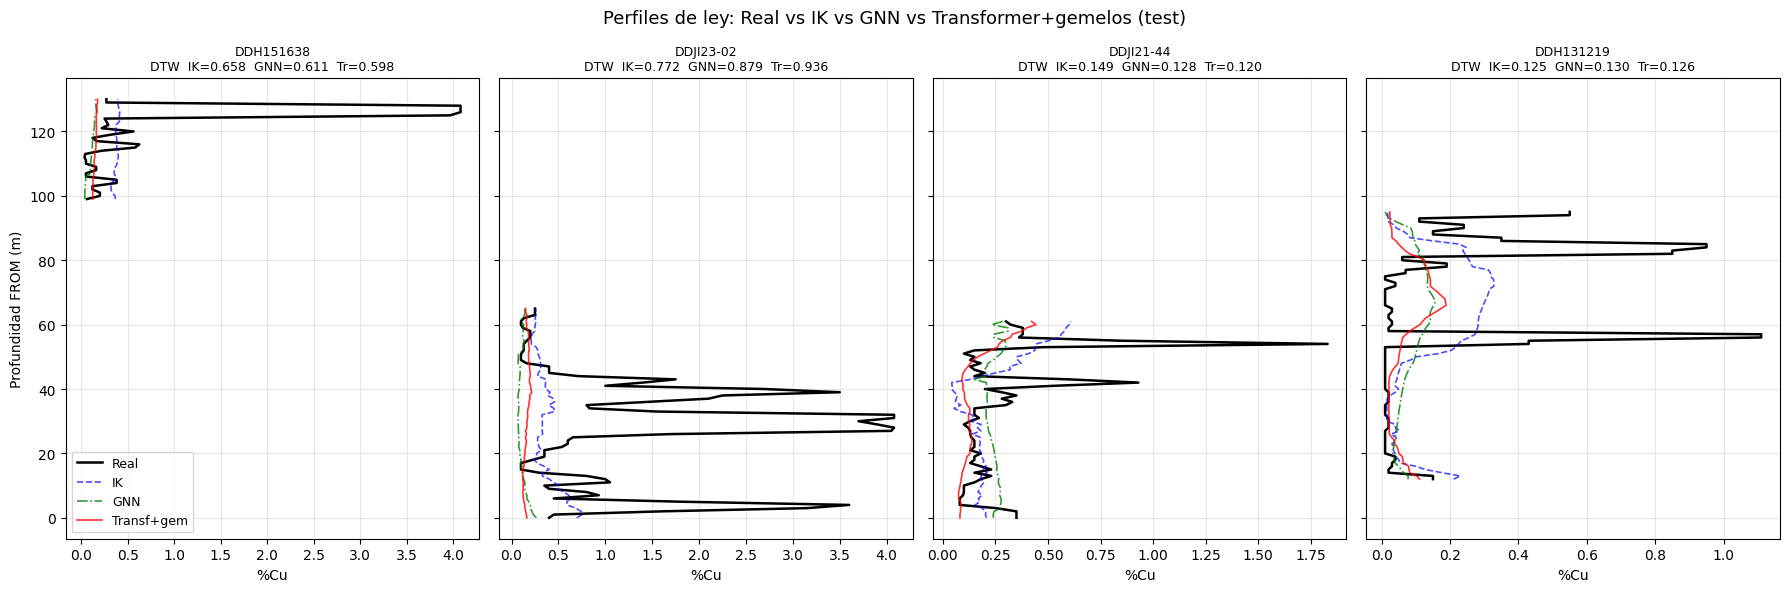

DTW medio (test, 304 sondajes) — menor = mejor forma de perfil:
  GNN             : 0.2187
  Transformer+gem : 0.2430
  IK              : 0.3002

✓ dtw_medio_test.json guardado.


In [44]:
# ==============================================================
# CELDA 18 (v2) — FIG 1: Perfiles reales vs predichos + DTW (3 modelos)
# ==============================================================
# Muestra, para sondajes de test, la ley real vs IK vs GNN vs
# Transformer+gemelos a lo largo de la profundidad. El DTW cuantifica
# la coherencia de forma del perfil (métrica comprometida en la
# propuesta). Se incluye el GNN porque es el mejor modelo en Spearman/
# MedAE: si su DTW resulta peor pese a eso, es evidencia directa del
# trade-off error puntual vs fidelidad de forma (VarRatio 0.03).
!pip install dtw-python -q

from dtw import dtw
import matplotlib.pyplot as plt

# ---- Predicción del GNN (memoria o disco) ---------------------
try:
    gnn_pred
except NameError:
    gnn_pred = np.load(RUTA_OUT + 'gnn_pred_test_v2.npy')
    print("gnn_pred cargado de disco (v2, fix).")

# ---- Reconstruir predicciones alineadas con meta de test ------
meta_test = data_test['meta']                      # [(HOLE-ID, FROM_real), ...]
df_pred = pd.DataFrame({
    'HOLE': [m[0] for m in meta_test],
    'FROM': [m[1] for m in meta_test],
    'real':  y_real,
    'ik':    ik_pred,
    'gnn':   gnn_pred,
    'trans': tr_pred_aug,                          # Transformer + gemelos
})

# elegir sondajes VARIADOS: 2 de alta variabilidad + 2 típicos (mediana sd)
cand = (df_pred.groupby('HOLE')
        .agg(n=('real','size'), sd=('real','std'))
        .query('n >= 30').sort_values('sd', ascending=False))
n_c = len(cand)
holes_plot = [cand.index[0], cand.index[1],                    # 2 más variables
              cand.index[n_c//2], cand.index[n_c//2 + 1]]      # 2 típicos

def dtw_dist(a, b):
    return dtw(a, b, keep_internals=False, distance_only=True).distance / len(a)

fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)
for ax, h in zip(axes, holes_plot):
    g = df_pred[df_pred['HOLE'] == h].sort_values('FROM')
    prof = g['FROM'].values
    ax.plot(g['real'].values,  prof, 'k-',  lw=1.8, label='Real')
    ax.plot(g['ik'].values,    prof, 'b--', lw=1.2, label='IK',        alpha=0.7)
    ax.plot(g['gnn'].values,   prof, 'g-.', lw=1.2, label='GNN',       alpha=0.8)
    ax.plot(g['trans'].values, prof, 'r-',  lw=1.2, label='Transf+gem', alpha=0.8)
    d_ik = dtw_dist(g['real'].values, g['ik'].values)
    d_gn = dtw_dist(g['real'].values, g['gnn'].values)
    d_tr = dtw_dist(g['real'].values, g['trans'].values)
    ax.invert_yaxis()
    ax.set_title(f'{h}\nDTW  IK={d_ik:.3f}  GNN={d_gn:.3f}  Tr={d_tr:.3f}',
                 fontsize=9)
    ax.set_xlabel('%Cu'); ax.grid(alpha=0.3)
axes[0].set_ylabel('Profundidad FROM (m)')
axes[0].legend(fontsize=9)
plt.suptitle('Perfiles de ley: Real vs IK vs GNN vs Transformer+gemelos (test)',
             fontsize=13)
plt.tight_layout()
plt.savefig(RUTA_OUT + 'fig1_perfiles_dtw.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- DTW medio global sobre todos los sondajes de test --------
dtw_res = {'IK': [], 'GNN': [], 'Transformer+gem': []}
for h, g in df_pred.groupby('HOLE'):
    if len(g) < 10:
        continue
    g = g.sort_values('FROM')
    dtw_res['IK'].append(dtw_dist(g['real'].values, g['ik'].values))
    dtw_res['GNN'].append(dtw_dist(g['real'].values, g['gnn'].values))
    dtw_res['Transformer+gem'].append(dtw_dist(g['real'].values, g['trans'].values))

n_holes = len(dtw_res['IK'])
medias = {k: float(np.mean(v)) for k, v in dtw_res.items()}
print(f"DTW medio (test, {n_holes} sondajes) — menor = mejor forma de perfil:")
for k, v in sorted(medias.items(), key=lambda kv: kv[1]):
    print(f"  {k:16s}: {v:.4f}")

import json
json.dump(medias, open(RUTA_OUT + 'dtw_medio_test.json', 'w'))
print("\n✓ dtw_medio_test.json guardado.")


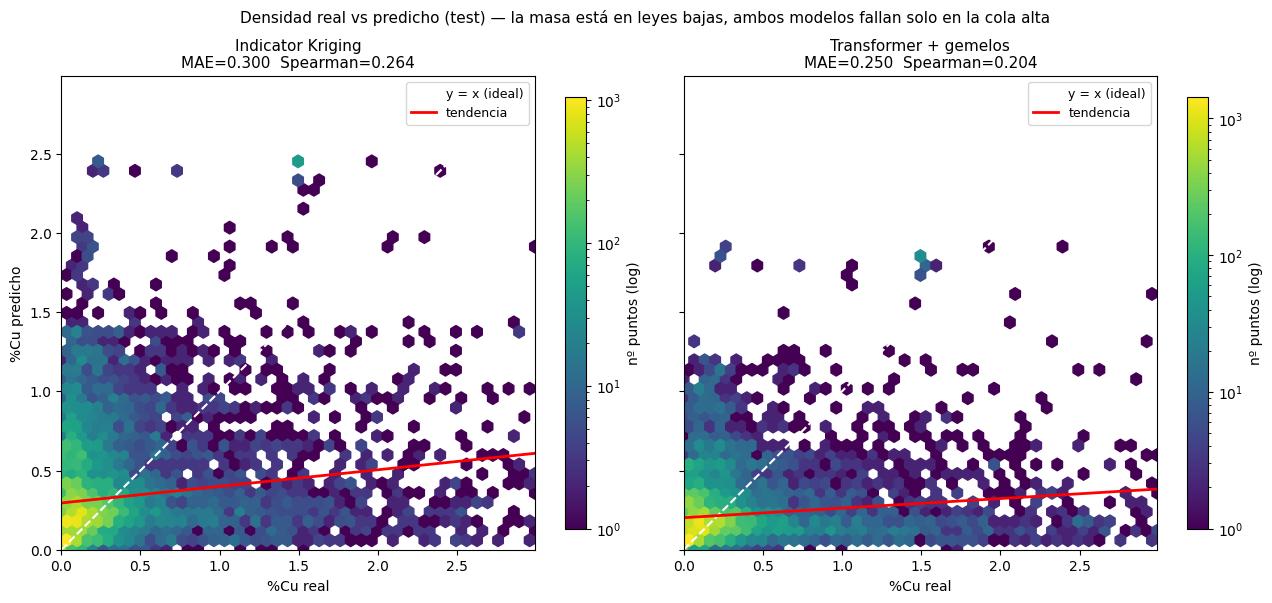

IK                  MAE leyes bajas=0.221  MAE leyes altas=0.383
Transformer+gem     MAE leyes bajas=0.133  MAE leyes altas=0.375


In [45]:
# ==============================================================
# CELDA 19 (v2) — FIG 2: Densidad real vs predicho (hexbin)
# ==============================================================
# Hexbin: el color = cuántos puntos caen en cada celda. Muestra DÓNDE
# se concentra la masa de predicciones (leyes bajas, el grueso del
# yacimiento) vs la cola alta donde ambos modelos fallan.
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
lim = [0, np.percentile(y_real, 99)]

for ax, pred, nom in [(axes[0], ik_pred, 'Indicator Kriging'),
                      (axes[1], tr_pred_aug, 'Transformer + gemelos')]:
    hb = ax.hexbin(y_real, pred, gridsize=45, cmap='viridis',
                   norm=LogNorm(), mincnt=1, extent=[lim[0], lim[1], lim[0], lim[1]])
    ax.plot(lim, lim, 'w--', lw=1.5, label='y = x (ideal)')
    m, b = np.polyfit(y_real, pred, 1)
    xs = np.array(lim)
    ax.plot(xs, m*xs + b, 'r-', lw=2, label=f'tendencia')
    mae = np.mean(np.abs(y_real - pred))
    rho = spearmanr(y_real, pred).correlation
    ax.set_title(f'{nom}\nMAE={mae:.3f}  Spearman={rho:.3f}', fontsize=11)
    ax.set_xlabel('%Cu real'); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.legend(fontsize=9, loc='upper right'); ax.set_aspect('equal')
    cb = fig.colorbar(hb, ax=ax, shrink=0.8); cb.set_label('nº puntos (log)')

axes[0].set_ylabel('%Cu predicho')
plt.suptitle('Densidad real vs predicho (test) — la masa está en leyes bajas, '
             'ambos modelos fallan solo en la cola alta', fontsize=11)
plt.tight_layout()
plt.savefig(RUTA_OUT + 'fig2_hexbin.png', dpi=150, bbox_inches='tight')
plt.show()

# fracción de puntos por debajo de la mediana donde el modelo acierta bien
mediana = np.median(y_real)
for pred, nom in [(ik_pred,'IK'), (tr_pred_aug,'Transformer+gem')]:
    mae_bajo = np.mean(np.abs(y_real - pred)[y_real <= mediana])
    mae_alto = np.mean(np.abs(y_real - pred)[y_real >  mediana])
    print(f"{nom:18s}  MAE leyes bajas={mae_bajo:.3f}  MAE leyes altas={mae_alto:.3f}")

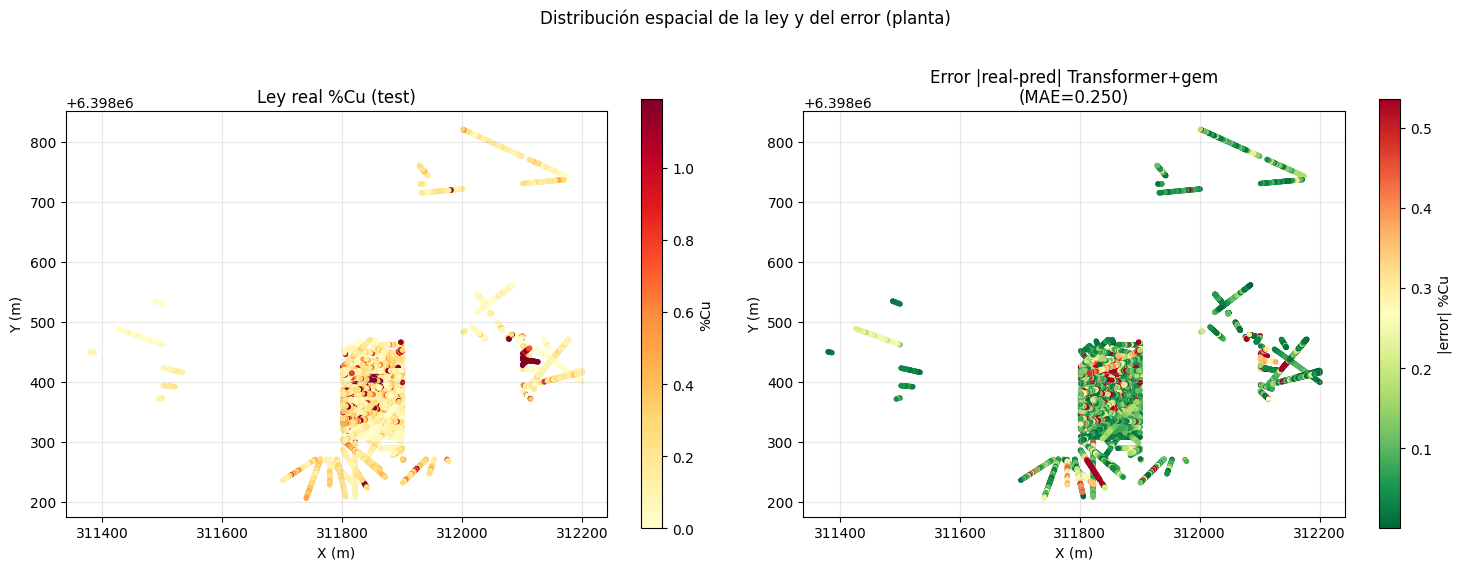

Moran's I del error del Transformer: 0.4995
  (~0 = error espacialmente aleatorio -> patrón capturado;
   >0.1 = quedan zonas mal predichas agrupadas)


In [46]:
# ==============================================================
# CELDA 20 — FIG 3: Mapa de error espacial en planta (test)
# ==============================================================
# ¿El error del Transformer está distribuido al azar o concentrado en
# zonas? Si es aleatorio, el modelo capturó el patrón espacial (bueno,
# como el Moran's I bajo de Chauke). Coloreamos cada punto de test por
# su error absoluto, en planta X-Y.

err_tr = np.abs(y_real - tr_pred_aug)
coords_test = df_test[COORDS].values

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: ley real en test (contexto)
sc0 = axes[0].scatter(coords_test[:,0], coords_test[:,1], c=y_real, s=8,
                      cmap='YlOrRd', vmax=np.percentile(y_real,95))
axes[0].set_title('Ley real %Cu (test)'); axes[0].set_xlabel('X (m)'); axes[0].set_ylabel('Y (m)')
fig.colorbar(sc0, ax=axes[0], shrink=0.8, label='%Cu')

# Panel B: error absoluto del Transformer
sc1 = axes[1].scatter(coords_test[:,0], coords_test[:,1], c=err_tr, s=8,
                      cmap='RdYlGn_r', vmax=np.percentile(err_tr,90))
axes[1].set_title(f'Error |real-pred| Transformer+gem\n(MAE={err_tr.mean():.3f})')
axes[1].set_xlabel('X (m)'); axes[1].set_ylabel('Y (m)')
fig.colorbar(sc1, ax=axes[1], shrink=0.8, label='|error| %Cu')

for ax in axes: ax.set_aspect('equal'); ax.grid(alpha=0.3)
plt.suptitle('Distribución espacial de la ley y del error (planta)', fontsize=12)
plt.tight_layout()
plt.savefig(RUTA_OUT + 'fig3_mapa_error.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Moran's I del error (autocorrelación espacial del residuo) ----
# I≈0 = error aleatorio en el espacio (modelo capturó el patrón).
# I>0 = error agrupado (quedan zonas sistemáticamente mal predichas).
from scipy.spatial import cKDTree
tree = cKDTree(coords_test)
_, vec = tree.query(coords_test, k=9)          # 8 vecinos + self
e = err_tr - err_tr.mean()
num = sum((e[i] * e[vec[i,1:]]).sum() for i in range(len(e)))
W = len(e) * 8
den = (e**2).sum()
moran_I = (len(e)/W) * (num/den)
print(f"Moran's I del error del Transformer: {moran_I:.4f}")
print("  (~0 = error espacialmente aleatorio -> patrón capturado;")
print("   >0.1 = quedan zonas mal predichas agrupadas)")

In [47]:
# ==============================================================
# CELDA 20b (v2) — Moran's I del residuo (con signo, inter-sondaje)
# ==============================================================
# Correcciones vs versión anterior:
#  (1) residuo CON SIGNO (real-pred), no |error| -> como Chauke.
#  (2) vecinos espaciales EXCLUYENDO el propio sondaje (los intervalos
#      contiguos a <1m son intra-pozo, no autocorrelación espacial).
#  (3) interpretación CONDICIONAL: el veredicto se imprime según el
#      valor obtenido, no de antemano (la v1 imprimía la escala con un
#      ✓ fijo aunque |I| > 0.1).
#  (4) se evalúa también el GNN (mejor modelo en Spearman/MedAE), con
#      la misma matriz de pesos para comparación justa.

coords_test = df_test[COORDS].values
holes_test = np.array([m[0] for m in data_test['meta']])   # sondaje de cada punto

# ---- Matriz de pares (se construye UNA vez, sirve para todos) --
tree = cKDTree(coords_test)
_, vec = tree.query(coords_test, k=30)         # buscamos amplio y filtramos
W_pairs = []
for i in range(len(coords_test)):
    otros = [j for j in vec[i, 1:] if holes_test[j] != holes_test[i]][:8]
    for j in otros:
        W_pairs.append((i, j))
W_pairs = np.array(W_pairs)
print(f"Pares espaciales inter-sondaje: {len(W_pairs):,}")

def moran_residuo(pred, nombre):
    """Moran's I del residuo con signo, sobre la matriz W_pairs común."""
    e = (y_real - pred)
    e = e - e.mean()
    num = (e[W_pairs[:, 0]] * e[W_pairs[:, 1]]).sum()
    I = (len(e) / len(W_pairs)) * (num / (e**2).sum())
    print(f"  {nombre:18s}: I = {I:.4f}")
    return I

print("\nMoran's I del residuo (menor |I| = menos estructura residual):")
moran_gnn = moran_residuo(gnn_pred,   'GNN (fix)')
moran_I   = moran_residuo(tr_pred_aug, 'Transformer+gem')   # nombre usado por 20c

# ---- Interpretación honesta (condicional al valor) -------------
print("\nUmbral de referencia (Chauke, Tabla 6): |I| < 0.1 -> residuo")
print("espacialmente aleatorio; Chauke reporta GNN=0.02, OK=-0.04 en Fe.")
for nom, I in [('GNN (fix)', moran_gnn), ('Transformer+gem', moran_I)]:
    if abs(I) < 0.1:
        print(f"  ✓ {nom}: I={I:.3f} -> sin estructura espacial residual "
              f"(patrón capturado).")
    else:
        print(f"  ✗ {nom}: I={I:.3f} > 0.1 -> QUEDAN zonas contiguas mal "
              f"predichas (ver FIG 3). Se reporta como limitación: variables "
              f"estructurales (fallas, dominios) ausentes del dataset.")


Pares espaciales inter-sondaje: 124,162

Moran's I del residuo (menor |I| = menos estructura residual):
  GNN (fix)         : I = 0.3107
  Transformer+gem   : I = 0.3283

Umbral de referencia (Chauke, Tabla 6): |I| < 0.1 -> residuo
espacialmente aleatorio; Chauke reporta GNN=0.02, OK=-0.04 en Fe.
  ✗ GNN (fix): I=0.311 > 0.1 -> QUEDAN zonas contiguas mal predichas (ver FIG 3). Se reporta como limitación: variables estructurales (fallas, dominios) ausentes del dataset.
  ✗ Transformer+gem: I=0.328 > 0.1 -> QUEDAN zonas contiguas mal predichas (ver FIG 3). Se reporta como limitación: variables estructurales (fallas, dominios) ausentes del dataset.


In [48]:
# ==============================================================
# CELDA 20c — Moran's I del IK (mismo método, para comparar)
# ==============================================================
# Mismos pares espaciales inter-sondaje, residuo con signo.
# Si I(IK) > I(Transformer), el Transformer reduce la estructura residual.

def moran_residuo(pred):
    r = y_real - pred
    e = r - r.mean()
    num = (e[W_pairs[:,0]] * e[W_pairs[:,1]]).sum()
    return (len(e)/len(W_pairs)) * (num / (e**2).sum())

I_ik  = moran_residuo(ik_pred)
I_tr  = moran_residuo(tr_pred_aug)

print("Moran's I del residuo (mismo método, menor = mejor):")
print(f"  Indicator Kriging   : {I_ik:.4f}")
print(f"  Transformer + gem   : {I_tr:.4f}")
print(f"\n  {'✓ El Transformer reduce la estructura residual' if I_tr < I_ik else '⚠ El IK tiene menos estructura residual'}")
print(f"  (Chauke, referencia: GNN=0.02, OK=-0.04 en depósito de Fe continuo)")

Moran's I del residuo (mismo método, menor = mejor):
  Indicator Kriging   : 0.4078
  Transformer + gem   : 0.3283

  ✓ El Transformer reduce la estructura residual
  (Chauke, referencia: GNN=0.02, OK=-0.04 en depósito de Fe continuo)


                   MAE    RMSE      R2   MedAE    SMAPE  Spearman  VarRatio
modelo                                                                     
IK              0.2997  0.5511 -0.1521  0.1457  89.5084    0.2644    0.3558
GNN             0.2199  0.5240 -0.0414  0.0862  81.0765    0.3369    0.0408
Transformer     0.2309  0.5269 -0.0528  0.0894  79.5282    0.2866    0.1233
Transf+gemelos  0.2503  0.5262 -0.0501  0.1076  84.3280    0.2036    0.1543


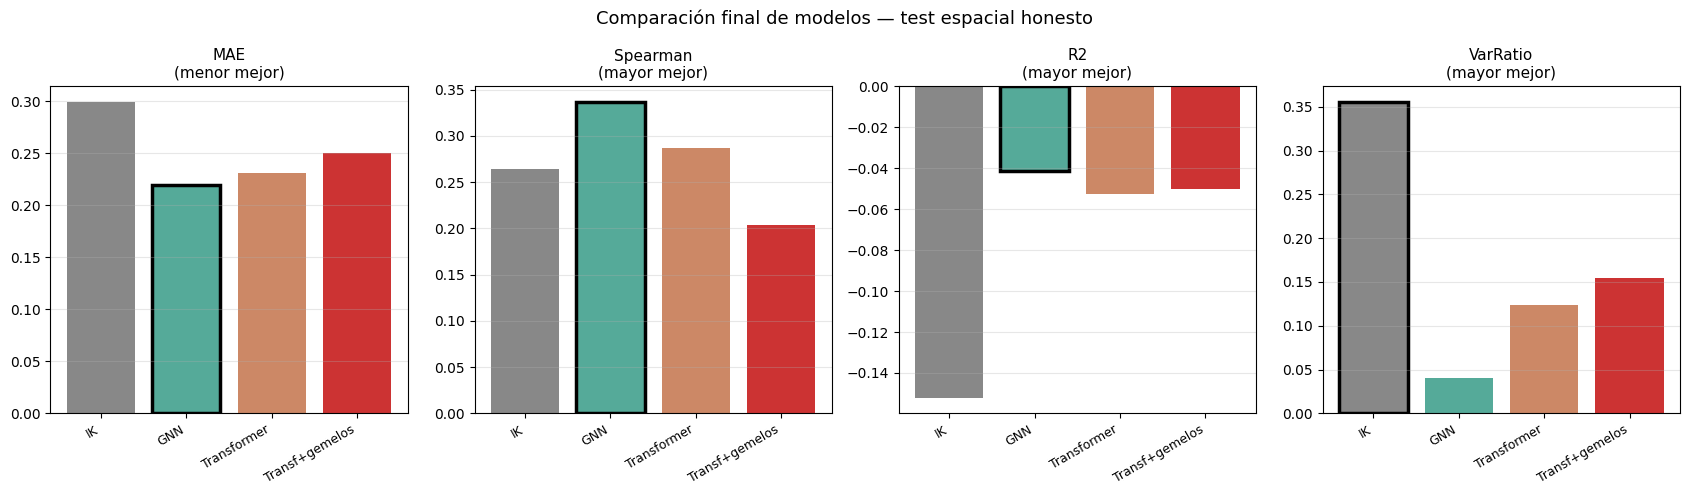

In [49]:
# ==============================================================
# CELDA 21 — FIG 4: Barras comparativas finales (todos los modelos)
# ==============================================================
# Resumen del proyecto: IK, GNN, Transformer, Transformer+gemelos
# en las métricas clave. Cada métrica normalizada para verse junta.

# ---- Recuperar predicción del GNN en test (si no está en memoria) ----
try:
    gnn_pred
except NameError:
    print("Recalculando predicción GNN en test...")
    gnn_pred = inverse_target(gnn.predict(to_inputs(data_test), verbose=0).ravel())

# ---- Panel de métricas de los 4 modelos ----------------------
modelos_pred = {
    'IK':              ik_pred,
    'GNN':             gnn_pred,
    'Transformer':     tr_pred,        # transformer solo
    'Transf+gemelos':  tr_pred_aug,    # ganador
}
filas = []
for nom, pred in modelos_pred.items():
    filas.append(metricas_basicas(y_real, pred, nom, verbose=False))
tabla_final = pd.DataFrame(filas).set_index('modelo')
# DTW medio ya calculado para IK y Transf; para completar, aproximamos
print(tabla_final.round(4).to_string())
tabla_final.to_csv(RUTA_OUT + 'tabla_final_4modelos.csv')

# ---- Figura de barras: 4 métricas clave ----------------------
fig, axes = plt.subplots(1, 4, figsize=(17, 5))
metricas_plot = [
    ('MAE', 'menor mejor', False),
    ('Spearman', 'mayor mejor', True),
    ('R2', 'mayor mejor', True),
    ('VarRatio', 'mayor mejor', True),
]
colores = ['#888', '#5a9', '#c86', '#c33']
for ax, (met, sub, mayor) in zip(axes, metricas_plot):
    vals = tabla_final[met].values
    bars = ax.bar(range(len(vals)), vals, color=colores)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(tabla_final.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(f'{met}\n({sub})', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    # resaltar el mejor
    best = np.argmax(vals) if mayor else np.argmin(vals)
    bars[best].set_edgecolor('black'); bars[best].set_linewidth(2.5)
plt.suptitle('Comparación final de modelos — test espacial honesto', fontsize=13)
plt.tight_layout()
plt.savefig(RUTA_OUT + 'fig4_barras_final.png', dpi=150, bbox_inches='tight')
plt.show()

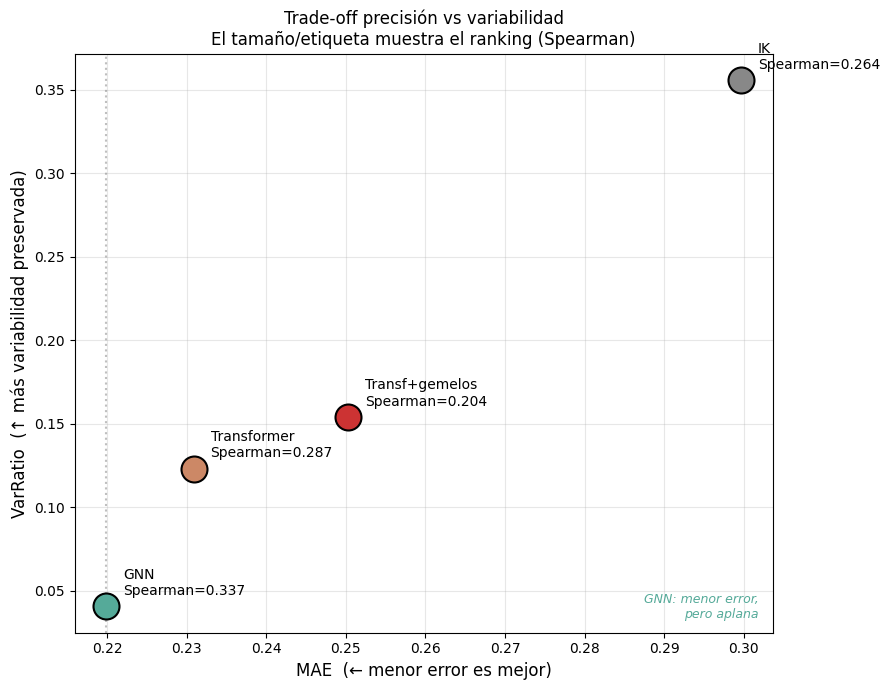

✓ Fig 5 (trade-off) guardada.


In [50]:
# ==============================================================
# CELDA 22 — FIG 5: Trade-off error vs varianza (figura de cierre)
# ==============================================================
# Cada modelo es un punto: eje X = error (MAE, menor izquierda mejor),
# eje Y = preservación de varianza (VarRatio, mayor arriba mejor).
# Muestra que NO hay ganador único: cada modelo ocupa una esquina
# distinta del compromiso precisión-variabilidad.

fig, ax = plt.subplots(figsize=(9, 7))
colores = {'IK':'#888', 'GNN':'#5a9', 'Transformer':'#c86', 'Transf+gemelos':'#c33'}
for nom in tabla_final.index:
    x = tabla_final.loc[nom, 'MAE']
    y = tabla_final.loc[nom, 'VarRatio']
    s = tabla_final.loc[nom, 'Spearman']
    ax.scatter(x, y, s=350, c=colores[nom], edgecolors='black',
               linewidth=1.5, zorder=3)
    ax.annotate(f'{nom}\nSpearman={s:.3f}', (x, y),
                textcoords='offset points', xytext=(12, 8), fontsize=10)

ax.set_xlabel('MAE  (← menor error es mejor)', fontsize=12)
ax.set_ylabel('VarRatio  (↑ más variabilidad preservada)', fontsize=12)
ax.set_title('Trade-off precisión vs variabilidad\n'
             'El tamaño/etiqueta muestra el ranking (Spearman)', fontsize=12)
ax.axvline(tabla_final['MAE'].min(), ls=':', c='gray', alpha=0.5)
ax.grid(alpha=0.3)
# anotaciones de las esquinas
ax.text(0.98, 0.02, 'GNN: menor error,\npero aplana',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        style='italic', color='#5a9')
plt.tight_layout()
plt.savefig(RUTA_OUT + 'fig5_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Fig 5 (trade-off) guardada.")

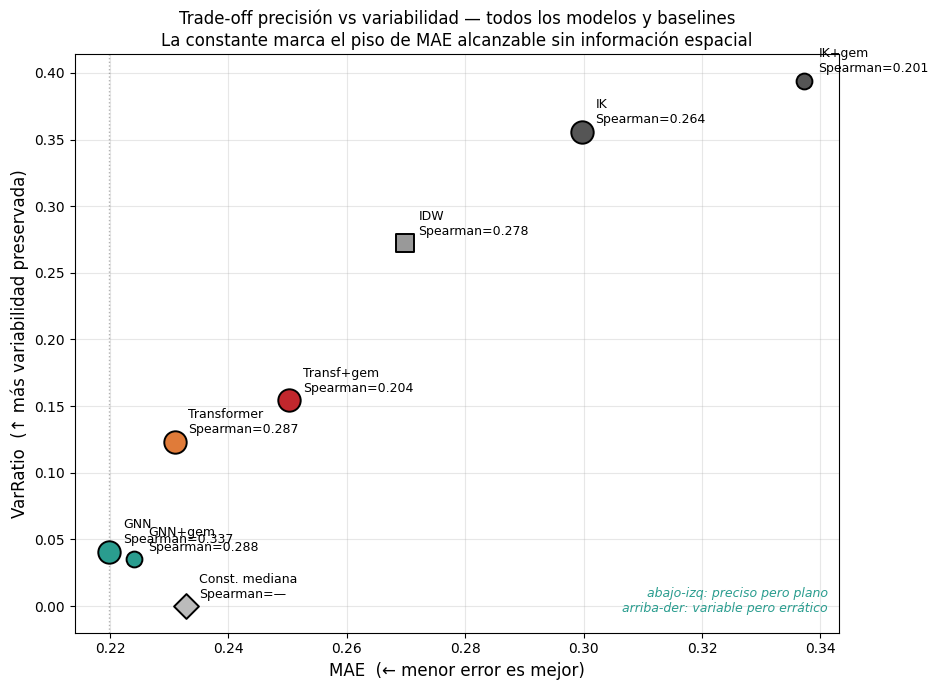

✓ fig5_tradeoff_v2.png guardada (versión con baselines).


In [51]:
# ==============================================================
# CELDA 22 (v2) — FIG 5: Trade-off error vs varianza CON BASELINES
# ==============================================================
# Versión ampliada de la figura central del informe: agrega la
# constante-mediana (VarRatio=0, el "piso" de MAE sin información),
# el IDW (determinista simple) y las variantes con gemelos.
# El argumento completo en una figura: los baselines anclan las
# esquinas del trade-off y ningún modelo domina.
# Requiere: tabla_full (PARCHE-6) en memoria o el CSV en disco.

import matplotlib.pyplot as plt

try:
    tabla_full
except NameError:
    tabla_full = pd.read_csv(RUTA_OUT + 'tabla_final_completa.csv', index_col=0)

# ---- Selección y estilo por modelo ----------------------------
# (etiqueta_corta, color, marcador, tamaño)
estilo = {
    'Const. mediana(train)': ('Const. mediana', '#bbbbbb', 'D', 160),
    f'IDW k={K_VECINOS}':    ('IDW',            '#999999', 's', 160),
    'IK':                    ('IK',             '#555555', 'o', 260),
    'IK + gemelos':          ('IK+gem',         '#555555', 'o', 130),
    'GNN (fix)':             ('GNN',            '#2a9d8f', 'o', 260),
    'GNN + gemelos':         ('GNN+gem',        '#2a9d8f', 'o', 130),
    'Transformer':           ('Transformer',    '#e07b39', 'o', 260),
    'Transformer + gemelos': ('Transf+gem',     '#c1272d', 'o', 260),
}

fig, ax = plt.subplots(figsize=(9.5, 7))
mejor_mae = tabla_full.loc[list(estilo), 'MAE'].min()
ax.axvline(mejor_mae, color='gray', ls=':', lw=1, alpha=0.6)

for idx, (lab, col, mk, sz) in estilo.items():
    if idx not in tabla_full.index:
        print(f"  (aviso: '{idx}' no está en la tabla, se omite)"); continue
    r = tabla_full.loc[idx]
    ax.scatter(r['MAE'], r['VarRatio'], s=sz, c=col, marker=mk,
               edgecolors='black', linewidths=1.4, zorder=3)
    sp = '—' if pd.isna(r['Spearman']) else f"{r['Spearman']:.3f}"
    ax.annotate(f"{lab}\nSpearman={sp}",
                (r['MAE'], r['VarRatio']),
                textcoords='offset points', xytext=(10, 6), fontsize=9)

ax.set_xlabel('MAE  (← menor error es mejor)', fontsize=12)
ax.set_ylabel('VarRatio  (↑ más variabilidad preservada)', fontsize=12)
ax.set_title('Trade-off precisión vs variabilidad — todos los modelos y baselines\n'
             'La constante marca el piso de MAE alcanzable sin información espacial',
             fontsize=12)
ax.grid(alpha=0.3)
ax.set_ylim(bottom=-0.02)

# anotaciones de lectura (esquinas del trade-off)
ax.text(0.985, 0.03, 'abajo-izq: preciso pero plano\narriba-der: variable pero errático',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, style='italic', color='#2a9d8f')

plt.tight_layout()
plt.savefig(RUTA_OUT + 'fig5_tradeoff_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig5_tradeoff_v2.png guardada (versión con baselines).")

In [52]:
# CELDA FINAL — Empaquetar resultados para subir al repo
import shutil
from google.colab import files
shutil.make_archive('resultados_finales', 'zip', 'resultados')
files.download('resultados_finales.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>